# ***INSTALL DEPENDENCIES***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install deep_translator
!pip install Sastrawi
!pip install transformers tensorflow tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
from deep_translator import GoogleTranslator
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize

# Download resource tokenisasi
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")
nltk.download("punkt_tab")  # <--- ini penting buat versi NLTK terbaru

# Download resource stopwords
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# ***LOAD DATA***

# ***PREPROCESSING DATA***

In [ ]:
!pip install deep_translator

In [ ]:
# === Install dependensi (jalankan sekali) ===
!pip -q install deep-translator Sastrawi emoji==2.10.1
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.5/421.5 kB 8.1 MB/s eta 0:00:00
Dependencies installed


In [ ]:
!pip install Sastrawi

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=db103dd700435061d0da935b7a2a053f1033a442b0c4598a1b12b9a98a58cdf2
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
import re
from deep_translator import GoogleTranslator
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

data = pd.read_csv("/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/tweet_semua.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      5844 non-null   int64  
 1   created_at               5844 non-null   object 
 2   favorite_count           5844 non-null   int64  
 3   full_text                5844 non-null   object 
 4   id_str                   5844 non-null   int64  
 5   image_url                1889 non-null   object 
 6   in_reply_to_screen_name  2288 non-null   object 
 7   lang                     5844 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              5844 non-null   int64  
 10  reply_count              5844 non-null   int64  
 11  retweet_count            5844 non-null   int64  
 12  tweet_url                5844 non-null   object 
 13  user_id_str              5844 non-null   int64  
 14  username                

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1977724223062970868,Mon Oct 13 13:12:53 +0000 2025,54,PENGUMUMAN! PENGUMUMAN! Ada kabar baik untuk ...,1977724223062970868,https://pbs.twimg.com/media/G3JJrAdbEAA2liW.jpg,NaN,in,NaN,1,1,12,https://x.com/undefined/status/197772422306297...,1874345307183697920,NaN
1,1977720697490206832,Mon Oct 13 12:58:53 +0000 2025,14,Haloooo minna-san! Pantengan akun kita ya bent...,1977720697490206832,NaN,NaN,in,NaN,0,0,2,https://x.com/undefined/status/197772069749020...,1874345307183697920,NaN
2,1977547712913690725,Mon Oct 13 12:19:24 +0000 2025,0,@LutfiHidayatR beberapa teman saya yang high p...,1977710763415330858,NaN,LutfiHidayatR,in,NaN,0,0,0,https://x.com/undefined/status/197771076341533...,226457177,NaN
3,1977682121969090793,Mon Oct 13 10:29:26 +0000 2025,1,@Ghazy_001 Damagenya gada obat kt anak jaman n...,1977683088290570337,NaN,Ghazy_001,in,NaN,0,1,0,https://x.com/undefined/status/197768308829057...,250986551,NaN
4,1977669492533809547,Mon Oct 13 09:35:46 +0000 2025,0,masa sekarang harus dikubur lagi gua mau #kabu...,1977669581880914381,NaN,tibitimes,in,NaN,0,0,0,https://x.com/undefined/status/197766958188091...,1523236556307570688,NaN


In [ ]:
import pandas as pd

# ubah kolom ke datetime
data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce')

# hapus data yang tidak punya tanggal valid
data = data.dropna(subset=['created_at'])

# urutkan mulai dari tahun 2025 ke bawah (descending)
data = data.sort_values(by='created_at', ascending=False).reset_index(drop=True)

# pisahkan tanggal dan waktu
data['tanggal'] = data['created_at'].dt.date
data['waktu']   = data['created_at'].dt.time

# tampilkan contoh hasil
data.head(10)

# simpan hasil ke file CSV
data.to_csv('data_urut_dari_2025.csv', index=False, encoding='utf-8')
print("File berhasil disimpan sebagai 'data_urut_dari_2025.csv'")


/tmp/ipython-input-3445716197.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce')


File berhasil disimpan sebagai 'data_urut_dari_2025.csv'


In [ ]:
df  = pd.DataFrame(data[['tanggal','waktu','full_text']])
df

,tanggal,waktu,full_text
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...
...,...,...,...
5839,2022-06-02,11:25:41,9. Ka. Kanwil Kemenkumham Sulsel Liberti Sitin...
5840,2022-06-02,11:14:54,Taspen Gandeng Pemerintah Daerah untuk Dorong ...
5841,2022-06-02,07:22:10,Ka. Kanwil Kemenkumham Sulsel Liberti Sitinjak...
5842,2022-06-02,02:40:40,9. Ka. Kanwil Kemenkumham Sulsel Liberti Sitin...


**PROSES HAPUS DATA DUPLIKAT**

---



In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tanggal    5844 non-null   object
 1   waktu      5844 non-null   object
 2   full_text  5844 non-null   object
dtypes: object(3)
memory usage: 137.1+ KB


,tanggal,waktu,full_text
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...


In [ ]:
# jumlah data duplikat
data = df[df.duplicated(subset="full_text", keep=False)]
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 211 entries, 29 to 5843
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tanggal    211 non-null    object
 1   waktu      211 non-null    object
 2   full_text  211 non-null    object
dtypes: object(3)
memory usage: 6.6+ KB


,tanggal,waktu,full_text
29,2025-10-18,12:26:28,Wakil Bupati menyampaikan apresiasi kepada sel...
30,2025-10-18,12:26:28,Wakil Bupati menyampaikan apresiasi kepada sel...
31,2025-10-18,12:25:28,Kehadiran Wakil Bupati menjadi bentuk dukungan...
32,2025-10-18,12:25:28,Kehadiran Wakil Bupati menjadi bentuk dukungan...
34,2025-10-18,12:18:37,Kehadiran Wakil Bupati menjadi bentuk dukungan...


In [ ]:
print("Jumlah data sebelum hapus duplikasi:", len(df))

# hapus data yang duplikat
df = df.drop_duplicates(subset=["full_text"], keep="first").reset_index(drop=True)

print("Jumlah data setelah hapus duplikasi:", len(df))

df

Jumlah data sebelum hapus duplikasi: 5844
Jumlah data setelah hapus duplikasi: 5713


,tanggal,waktu,full_text
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...
...,...,...,...
5708,2022-06-03,08:32:12,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...
5709,2022-06-03,05:01:54,Halo sobat Miso pada Hari Jumat 03 Juni 2022 K...
5710,2022-06-03,03:41:36,ASABRI bekerja sama dengan TASPEN Pemerintah D...
5711,2022-06-02,11:14:54,Taspen Gandeng Pemerintah Daerah untuk Dorong ...


**PROSES CLEANING**

---



In [ ]:
import re
import string
import nltk

# fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'http\S+|www\S+|https?:\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# fungsi untuk menghapus simbol dan karakter non-alfabet kecuali spasi
def remove_symbols_and_non_alpha(tweet):
    if tweet is not None and isinstance(tweet, str):
        # Hapus karakter non-alfabet kecuali spasi
        tweet = re.sub(r'[^a-zA-Z0-9\s]', ' ', tweet)
    return tweet

# fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d+', '', tweet)
    return tweet

# fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

# fungsi hapus hashtag symbol
def remove_hashtags(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'#', '', text)
    else:
        return text

# Fungsi hapus "amp;" (hasil HTML escape &amp;)
def remove_amp(text):
    if text is not None and isinstance(text, str):
        return text.replace("amp;", " ")
    else:
        return text

# fungsi hapus spasi berlebih
def remove_extra_spaces(text):
    if text is not None and isinstance(text, str):
        return re.sub(r"\s+", " ", text).strip()
    else:
        return text

# fungsi hapus retweet
def remove_retweet(text):
    if text is not None and isinstance(text, str):
        return re.sub(r"RT", " ", text)
    else:
        return text


df['cleaning'] = df['full_text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_usernames(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_hashtags(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols_and_non_alpha(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_amp(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_retweet(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_extra_spaces(x))

# # buang duplikat berdasarkan hasil cleaning
# df = df.drop_duplicates(subset=["cleaning"], keep="first").reset_index(drop=True)

# print("Jumlah data setelah hapus duplikasi:",  len(df))

df

,tanggal,waktu,full_text,cleaning
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...
...,...,...,...,...
5708,2022-06-03,08:32:12,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...
5709,2022-06-03,05:01:54,Halo sobat Miso pada Hari Jumat 03 Juni 2022 K...,Halo sobat Miso pada Hari Jumat Juni Kantor Im...
5710,2022-06-03,03:41:36,ASABRI bekerja sama dengan TASPEN Pemerintah D...,ASABRI bekerja sama dengan TASPEN Pemerintah D...
5711,2022-06-02,11:14:54,Taspen Gandeng Pemerintah Daerah untuk Dorong ...,Taspen Gandeng Pemerintah Daerah untuk Dorong ...


**PROSES CASE FOLDING**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,tanggal,waktu,full_text,cleaning,case_folding
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...


**Normalisasi Kata**

---



Load Kamus kata baku

In [ ]:
import pandas as pd

# auto-detect delimiter & handle encoding
kamus = pd.read_csv(
    "/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/new_kamus_kata_baku.csv",
    header=None,
    names=["kata_tidak_baku", "kata_baku"],
    encoding="latin-1",
    sep=None,           # auto-detect ',', ';', '\t', dsb (butuh engine='python')
    engine="python"
).dropna()

# bersihkan spasi & lower
kamus["kata_tidak_baku"] = kamus["kata_tidak_baku"].astype(str).str.strip().str.lower()
kamus["kata_baku"] = kamus["kata_baku"].astype(str).str.strip().str.lower()

# buat dictionary
alay_dict = dict(zip(kamus["kata_tidak_baku"], kamus["kata_baku"]))

print(f"Kamus termuat: {len(alay_dict):,} entri")
# contoh cek
for k in ["gk", "ga", "bgt", "aq"]:
    if k in alay_dict:
        print(f"{k} -> {alay_dict[k]}")


Kamus termuat: 15,189 entri
gk -> tidak
ga -> tidak
bgt -> banget
aq -> aku


In [ ]:
# fungsi untuk normalisasi kata
def normalize_text(text, alay_dict):
    words = text.split()
    normalized_words = [alay_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# terapkan fungsi normalisasi
df['normalisasi'] = df['case_folding'].apply(lambda x: normalize_text(x, alay_dict))

# ambil kolom yang relevan
# df = pd.DataFrame(df[['tanggal','waktu','full_text','translated_text','cleaning','case_folding','normalisasi']]) # Removed this line

df

,tanggal,waktu,full_text,cleaning,case_folding,normalisasi
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...
...,...,...,...,...,...,...
5708,2022-06-03,08:32:12,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,ketua fraksi gerindra dprd kabupaten kotawarin...,ketua fraksi gerindra dewan perwakilan rakyat ...
5709,2022-06-03,05:01:54,Halo sobat Miso pada Hari Jumat 03 Juni 2022 K...,Halo sobat Miso pada Hari Jumat Juni Kantor Im...,halo sobat miso pada hari jumat juni kantor im...,halo sobat miso pada hari jumat juni kantor im...
5710,2022-06-03,03:41:36,ASABRI bekerja sama dengan TASPEN Pemerintah D...,ASABRI bekerja sama dengan TASPEN Pemerintah D...,asabri bekerja sama dengan taspen pemerintah d...,asabri bekerja sama dengan taspen pemerintah d...
5711,2022-06-02,11:14:54,Taspen Gandeng Pemerintah Daerah untuk Dorong ...,Taspen Gandeng Pemerintah Daerah untuk Dorong ...,taspen gandeng pemerintah daerah untuk dorong ...,taspen gandeng pemerintah daerah untuk dorong ...


**TRANSLATE**

---



In [ ]:
import pandas as pd
import time
import concurrent.futures
from deep_translator import GoogleTranslator
from tqdm.notebook import tqdm

In [ ]:
# konfigurasi turbo
BATCH_SIZE = 20       # 20 tweet per request
MAX_WORKERS = 4       # mengerjakan 2 batch sekaligus (parallel)

# fungsi worker (dipanggil oleh thread)
def process_batch(chunk_data):
    """Fungsi ini akan dijalankan oleh workers secara paralel"""
    texts, src, tgt = chunk_data
    try:
        translator = GoogleTranslator(source=src, target=tgt)
        # pastikan data string dan tidak kosong
        clean_chunk = [str(x) if pd.notna(x) and str(x).strip() != '' else "." for x in texts]

        # translate
        res = translator.translate_batch(clean_chunk)

        # sedikit jeda agar tidak crash saat worker 1 dan 2 request barengan persis
        time.sleep(0.5)
        return res
    except Exception as e:
        # jika error, kembalikan teks aslinya (Fallback) agar data tidak hilang/error message
        return texts

# fungsi utama turbo manager
def run_turbo_translation(df, col_input, col_output, src, tgt):
    data_source = df[col_input].tolist()
    total_data = len(data_source)

    # 1. pecah data jadi chunks
    chunks = [data_source[i:i + BATCH_SIZE] for i in range(0, total_data, BATCH_SIZE)]

    # siapkan argumen untuk worker (text_chunk, source, target)
    work_args = [(chunk, src, tgt) for chunk in chunks]

    results_ordered = []

    print(f" Memulai Turbo Mode (Workers: {MAX_WORKERS}) | {src.upper()} -> {tgt.upper()}")

    # 2. eksekusi Parallel dengan ThreadPoolExecutor
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # gunakan executor.map agar hasil tetap urut sesuai input
        # tqdm membungkus proses map untuk menampilkan progress bar
        results_iterator = list(tqdm(executor.map(process_batch, work_args), total=len(chunks)))

        # gabungkan hasil chunks kembali jadi satu list panjang
        for batch_res in results_iterator:
            results_ordered.extend(batch_res)

    # 3. masukkan ke DataFrame
    df[col_output] = results_ordered
    return df

In [ ]:
# 1. TAHAP 1: Indo (Baku) -> Inggris
df = run_turbo_translation(df, 'normalisasi', 'text_english', 'auto', 'en')

# simpan checkpoint tahap 1
df.to_csv("turbo_checkpoint_step1.csv", index=False)
print("Tahap 1 Selesai & Tersimpan.")

 Memulai Turbo Mode (Workers: 4) | AUTO -> EN


  0%|          | 0/286 [00:00<?, ?it/s]

Tahap 1 Selesai & Tersimpan.


In [ ]:
# 2. TAHAP 2: Inggris -> Indo (Back Translation)
df = run_turbo_translation(df, 'text_english', 'translated_text', 'en', 'id')

# simpan hasil final translate
df.to_csv("turbo_final_translated.csv", index=False)
print("SELESAI! Cek kolom 'translated_text'.")

# tampilkan sampel
df.head()

 Memulai Turbo Mode (Workers: 4) | EN -> ID


  0%|          | 0/286 [00:00<?, ?it/s]

SELESAI! Cek kolom 'translated_text'.


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ..."
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ..."


**TOKENIZATION**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...,"[pemerintah, daerah, dan, dewan, perwakilan, r..."
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...,"[indonesia, merdeka, pada, setelah, perjuangan..."
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ...","[jika, seperti, kata, bapak, jokowidodo, ini, ..."
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...,"[pemerintah, kota, bekasi, maupun, pemerintah,..."
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ...","[pak, purbaya, ya, menteri, keuangan, isinya, ..."


**PROSES STOPWORD REMOVAL**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...,"[pemerintah, daerah, dan, dewan, perwakilan, r...","[pemerintah, daerah, dewan, perwakilan, rakyat..."
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...,"[indonesia, merdeka, pada, setelah, perjuangan...","[indonesia, merdeka, perjuangan, melawan, bela..."
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ...","[jika, seperti, kata, bapak, jokowidodo, ini, ...","[jokowidodo, pemerintah, daerah, menanggung, r..."
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...,"[pemerintah, kota, bekasi, maupun, pemerintah,...","[pemerintah, kota, bekasi, pemerintah, kabupat..."
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ...","[pak, purbaya, ya, menteri, keuangan, isinya, ...","[purbaya, ya, menteri, keuangan, isinya, lihat..."


**PROSES STEAMING**

---



In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['tokenize'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...,"[pemerintah, daerah, dan, dewan, perwakilan, r...","[pemerintah, daerah, dewan, perwakilan, rakyat...",perintah daerah dan dewan wakil rakyat daerah ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...,"[indonesia, merdeka, pada, setelah, perjuangan...","[indonesia, merdeka, perjuangan, melawan, bela...",indonesia merdeka pada telah juang panjang law...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ...","[jika, seperti, kata, bapak, jokowidodo, ini, ...","[jokowidodo, pemerintah, daerah, menanggung, r...",jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...,"[pemerintah, kota, bekasi, maupun, pemerintah,...","[pemerintah, kota, bekasi, pemerintah, kabupat...",perintah kota bekas maupun perintah kabupaten ...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ...","[pak, purbaya, ya, menteri, keuangan, isinya, ...","[purbaya, ya, menteri, keuangan, isinya, lihat...",pak purbaya ya menteri uang isi saya lihat sha...


In [ ]:
from collections import Counter

all_text = ' '.join(df['tokenize'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

df_freq.to_csv('frekuensi_kata_awal_with_filter_tahun.csv', index=False)
print("File 'frekuensi_kata_awal.csv' berhasil disimpan.")
df_freq.info()
df_freq

File 'frekuensi_kata_awal.csv' berhasil disimpan.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12166 entries, 0 to 12165
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Kata       12166 non-null  object
 1   Frekuensi  12166 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 190.2+ KB


,Kata,Frekuensi
0,daerah,4127
1,pemerintah,4022
2,dan,3131
3,yang,2920
4,di,2310
...,...,...
12161,suaragerindra,1
12162,miso,1
12163,unimuda,1
12164,kegiatanasabri,1


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5713 entries, 0 to 5712
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5713 non-null   object
 1   waktu             5713 non-null   object
 2   full_text         5713 non-null   object
 3   cleaning          5713 non-null   object
 4   case_folding      5713 non-null   object
 5   normalisasi       5713 non-null   object
 6   text_english      5713 non-null   object
 7   translated_text   5713 non-null   object
 8   tokenize          5713 non-null   object
 9   stopword removal  5713 non-null   object
 10  steming_data      5713 non-null   object
dtypes: object(11)
memory usage: 491.1+ KB


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...,"[pemerintah, daerah, dan, dewan, perwakilan, r...","[pemerintah, daerah, dewan, perwakilan, rakyat...",perintah daerah dan dewan wakil rakyat daerah ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...,"[indonesia, merdeka, pada, setelah, perjuangan...","[indonesia, merdeka, perjuangan, melawan, bela...",indonesia merdeka pada telah juang panjang law...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ...","[jika, seperti, kata, bapak, jokowidodo, ini, ...","[jokowidodo, pemerintah, daerah, menanggung, r...",jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...,"[pemerintah, kota, bekasi, maupun, pemerintah,...","[pemerintah, kota, bekasi, pemerintah, kabupat...",perintah kota bekas maupun perintah kabupaten ...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ...","[pak, purbaya, ya, menteri, keuangan, isinya, ...","[purbaya, ya, menteri, keuangan, isinya, lihat...",pak purbaya ya menteri uang isi saya lihat sha...


In [ ]:
#  POST-STEMMING REFINEMENT
#  (Stopword aman + Normalisasi kata tidak baku)
import pandas as pd
import re
from collections import Counter

# Opsional: muat frekuensi awal (jika ada), untuk bantu deteksi noise
freq_path = "/content/frekuensi_kata_awal_with_filter_tahun.csv"
try:
    df_freq_initial = pd.read_csv(freq_path)  # kolom: 'Kata','Frekuensi'
except Exception:
    df_freq_initial = None

df['tokenize'] = df['tokenize'].astype(str)

# (A) Proteksi frasa domain sebelum stopword (jadi satu token)
PROTECT_PHRASES = [
    "pelayanan publik", "mal pelayanan publik", "pelayanan terpadu",
    "administrasi kependudukan", "layanan digital", "loket pelayanan",
    "nomor antrean", "pajak daerah", "pajak bumi dan bangunan",
    "perubahan alamat", "surat pindah", "kartu keluarga", "kartu tanda penduduk",
    "nomor induk kependudukan", "tanda tangan elektronik", "tanda tangan digital"
]
def protect_phrases(text:str) -> str:
    t = text.lower()
    for p in sorted(PROTECT_PHRASES, key=len, reverse=True):
        t = t.replace(p, p.replace(" ", "_"))
    # satukan variasi tagar jadi satu token
    t = re.sub(r"#?\s*kabur\s*aja\s*dulu", "kabur_aja_dulu", t, flags=re.I)
    t = re.sub(r"#kaburajadulu", "kabur_aja_dulu", t, flags=re.I)
    return t

df['tokenize'] = df['tokenize'].apply(protect_phrases)

# (B) Sentiment keepers KHUSUS domain layanan pemda (jangan dihapus)
sentiment_keepers = set("""
tidak tak bukan jangan belum kurang lebih
bagus baik cepat lambat parah kacau buruk jelek memuaskan tidak_memuaskan
ribet mudah jelas tidak_jelas transparan tidak_transparan
antre antrean nomor_antrean loket offline online eror error down mainten
aplikasi website sistem server
keluhan komplain saran pujian kritik kecewa marah puas tidak_puas
korupsi pungli pungutan liar gratifikasi suap oknum
biaya mahal murah
pemda pemkot pemkab pemprov dinas disdukcapil dukcapil dishub diskominfo
kelurahan kecamatan kantor_camat lurah bupati wali_kota walikota gubernur
administrasi layanan pelayanan pelayanan_publik mal_pelayanan_publik birokrasi
perizinan izin nik ktp kk akta akta_kelahiran akta_kematian
bpjs samsat pajak pbb nopol
kabur_aja_dulu
""".split())

# (C) Stopword dasar (boleh pakai Sastrawi jika ada) + slang umum Twitter
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    base_stop = set(StopWordRemoverFactory().get_stop_words())
except Exception:
    base_stop = set("""
ada adalah adanya agar akan amat anda andaikan antar antara apabila apalagi apatah apun atau
bahkan bahwa banyak begitu benar bersama beserta sekitar seperti sehingga sesudah selain selama selalu
semua semula sendiri sering setelah setidaknya setiap serta sudah supaya tanpa terhadap tentang tentu
tentunya tetap tetapi tiap ya yang ini itu jadi karena kalau namun dari juga masih
""".split())

slang_stop = set("""
nih sih deh dong kok loh lho lah woi woy weh wew wkwk wk wkwwk wkwkwk
haha hehe hihi hahaha hehehe hehehehe
yaa yah yha yoi yup yep yups
btw cmiiw imo imho tbh idk otw rt
kyk gitu gini begini begitu doang bangettt
anj anjay anjg ajg bangke goblok tolol bego
plis please plislah pliss pls
lol lmao rofl
""".split())

foreign_stop = set("of to is in no the for and or on at by with from into via".split())

# (opsional) frekuensi untuk bantu singkirkan token 1–2 huruf
freq_noise = set()
try:
    df_freq_initial = pd.read_csv("frekuensi_kata_awal_with_filter_tahun.csv")
    pendek = set(k for k in df_freq_initial['Kata'].astype(str) if len(k) <= 2)
    freq_noise |= pendek
    high_freq_candidates = set("yang dan di itu ini ya aja sih deh dong lah loh kok".split())
    freq_set = set(df_freq_initial['Kata'].astype(str).tolist())
    freq_noise |= (high_freq_candidates & freq_set)
except Exception:
    pass

hapus_kata_final = (base_stop | slang_stop | foreign_stop | freq_noise) - sentiment_keepers

def filter_stopwords_safe(text: str) -> str:
    toks = text.split()
    toks = [t for t in toks if t and (t not in hapus_kata_final)]
    return " ".join(toks)

df['tokenize'] = df['tokenize'].apply(filter_stopwords_safe)

# (D) Normalisasi kata tidak baku -> baku (KHUSUS domain pemda)
re_dupe = re.compile(r'(.)\1{2,}')  # huruf berulang ≥3

kamus_tidak_baku = {
    # negasi/variasi
    "ga":"tidak","gk":"tidak","gak":"tidak","ngga":"tidak","nggak":"tidak","engga":"tidak","enggak":"tidak","tdk":"tidak","bkn":"bukan",
    # fungsi
    "yg":"yang","dgn":"dengan","dlm":"dalam","utk":"untuk","u":"untuk","dr":"dari",
    "sdh":"sudah","udh":"sudah","sj":"saja","aja":"saja","tp":"tapi","krn":"karena","kpn":"kapan","gmn":"gimana","trs":"terus",
    # antre
    "antri":"antre","antrian":"antrean","mengantri":"mengantre","ngantri":"mengantre",
    # dukcapil
    "dukcapil":"disdukcapil","disduk":"disdukcapil","capil":"disdukcapil", "perintah":"pemerintah", "layan":"layanan",
    # pemerintah
    "pemko":"pemkot","pemkota":"pemkot","walikota":"wali kota",
    # dokumen & istilah
    "ktp-el":"ktp elektronik","e-ktp":"elektronik ktp","kk-el":"kk elektronik","e-kk":"elektronik kk","nmr":"nomor","no":"nomor",
    "nik-":"nik","nikk":"nik","nopolisi":"nomor polisi",
    # aplikasi/sistem
    "app":"aplikasi","apps":"aplikasi","web":"website","site":"website","servernya":"server",
    "maintenis":"maintenance","maintain":"maintenance","downnya":"down",
    # kualitas & pengalaman
    "lambrett":"lambat","lemot":"lambat","nge-lag":"lag","ngehang":"hang","lemotnya":"lambat",
    "taktau":"tidak tahu","xtau":"tahu","gatau":"tidak tahu",
    # tagar (jaga-jaga)
    "kaburajadulu":"kabur_aja_dulu"
}

def shrink_repeats(token:str) -> str:
    return re_dupe.sub(r'\1\1', token)

def normalize_token(tok: str) -> str:
    t = tok.strip().lower().strip("’'`\"()[]{}.,!?;:")
    t = shrink_repeats(t)
    return kamus_tidak_baku.get(t, t)

def normalize_text(text: str) -> str:
    return " ".join(normalize_token(t) for t in text.split())

df['tokenize'] = df['tokenize'].apply(normalize_text)

# (E) Simpan snapshot & frekuensi terbaru (untuk cek)
df[['full_text','tokenize']].to_csv("snapshot_after_refine_pemda.csv", index=False)

joined = " ".join(df['tokenize'].astype(str))
joined = re.sub(r'[^a-zA-Z_\\s]', ' ', joined.lower())
word_list = [w for w in joined.split() if w.strip()]
df_freq_new = pd.DataFrame(Counter(word_list).most_common(), columns=['Kata','Frekuensi'])
df_freq_new.to_csv("frekuensi_kata_SETELAH_refine_pemda.csv", index=False)

print("Refinement khusus PEMDA selesai. File:")
print("• snapshot_after_refine_pemda.csv")
print("• frekuensi_kata_SETELAH_refine_pemda.csv")

# (Opsional) tampilkan 30 kata teratas & 30 kata yang dihapus (jika ada)
top30 = df_freq_new.head(30)
print("\n Top 30 setelah refinement:")
print(top30.to_string(index=False))

Refinement khusus PEMDA selesai. File:
• snapshot_after_refine_pemda.csv
• frekuensi_kata_SETELAH_refine_pemda.csv

 Top 30 setelah refinement:
          Kata  Frekuensi
        daerah       4127
    pemerintah       4026
           dan       3131
          yang       2920
            di       2310
kabur_aja_dulu       2026
       layanan       1853
         untuk       1383
           ini       1221
     indonesia       1160
         tidak       1043
        dengan        980
         dalam        957
          dari        957
        negara        862
            ke        725
    masyarakat        699
           ada        602
          kita        602
         pusat        601
          pada        598
     kabupaten        590
        rakyat        581
        publik        569
     kesehatan        563
          bisa        544
            ya        527
           itu        480
         sudah        448
          juga        434


In [ ]:
import re
import pandas as pd
from collections import Counter

# shrink huruf berulang: "kabuuur ajaaa duluu" -> "kabuur aj aa duluu" -> normal
re_dupe = re.compile(r'(.)\1{2,}')  # 3x+ huruf sama -> 2x
def shrink_repeats(s: str) -> str:
    return re_dupe.sub(r'\1\1', s or "")

# cek apakah token/frasa adalah varian "kaburajadulu"
def is_kaburajadulu_variant(text: str) -> bool:
    if not text:
        return False
    t = shrink_repeats(text.lower())
    # buang semua non-huruf agar "kabur_aja-dulu", "#kabur aja dulu" tetap terbaca
    t_letters = re.sub(r'[^a-z]', '', t)
    # syarat: harus berurutan kabur -> aja -> dulu
    return (t_letters.find('kabur') != -1 and
            t_letters.find('aja', t_letters.find('kabur')+5) != -1 and
            t_letters.find('dulu', t_letters.find('aja')+3) != -1)

# ubah SEMUA varian apa pun menjadi token tunggal "kaburajadulu"
# contoh yang tertangani: "#kabur aja dulu", "kabur_aja_dulu", "Kabur-Aja-Dulu", "kabuurr ajaaa duluu", dst.
VARIANT_PATTERN = re.compile(
    r"""
    \#?                      # opsional '#'
    k+ a+ b+ u+ r+           # 'kabur' dgn toleransi huruf berulang
    [\s_\-\.\,]*             # opsional spasi/underscore/hyphen/punct
    a+ j+ a+                 # 'aja'
    [\s_\-\.\,]*             # pemisah opsional
    d+ u+ l+ u+              # 'dulu'
    """, re.IGNORECASE | re.VERBOSE
)

def standardize_kaburajadulu(text: str) -> str:
    if not isinstance(text, str):
        return text
    t = shrink_repeats(text)
    # ganti SEMUA kemunculan varian menjadi 'kaburajadulu'
    t = VARIANT_PATTERN.sub("kaburajadulu", t)
    return t

# A) STANDARISASI DI DATAFRAME (pilih kolom yang kamu pakai)
# Jika analisis memakai kolom 'steming_data', standariskan di situ:
df['tokenize'] = df['tokenize'].astype(str).apply(standardize_kaburajadulu)

# jika ingin sekaligus di 'cleaning' / 'translated_text' / 'full_text' (opsional):
# for col in ['cleaning', 'translated_text', 'full_text']:
#     if col in df.columns:
#         df[col] = df[col].astype(str).apply(standardize_kaburajadulu)

# B) DETEKSI VARIAN YANG SUDAH ADA DI FREKUENSI (SEBELUM NORMALISASI)
# jika punya file frekuensi mentah, muat & cari kandidat varian.
try:
    freq_path = "frekuensi_kata_SETELAH_refine_pemda.csv"  # ganti jika nama filenya beda
    df_freq = pd.read_csv(freq_path)  # kolom: 'Kata','Frekuensi'
    df_freq['Kata'] = df_freq['Kata'].astype(str)

    # ambil hanya token yang merupakan varian
    variants = []
    for kata, frek in df_freq[['Kata','Frekuensi']].values:
        if is_kaburajadulu_variant(kata) and kata != 'kaburajadulu':
            # simulasikan hasil normalisasi untuk info
            standardized = standardize_kaburajadulu(kata)
            variants.append((kata, int(frek), standardized))

    df_variants = pd.DataFrame(variants, columns=['Kata_Varian','Frekuensi','Akan_Diganti_Jadi'])
    if not df_variants.empty:
        df_variants.sort_values(['Frekuensi','Kata_Varian'], ascending=[False, True], inplace=True)
        df_variants.to_csv("kaburajadulu_variants_found.csv", index=False)
        print(f"Tersimpan: kaburajadulu_variants_found.csv (rows={len(df_variants)})")
    else:
        print("Tidak ditemukan varian kaburajadulu di file frekuensi.")

except Exception as e:
    print(f"(Lewati deteksi varian frekuensi) Alasan: {e}")

print("Standarisasi ke 'kaburajadulu' selesai.")

Tersimpan: kaburajadulu_variants_found.csv (rows=2)
Standarisasi ke 'kaburajadulu' selesai.


In [ ]:
import re
import pandas as pd
from collections import Counter

#  A) DETEKSI & REKAP BENTUK MENEMPEL
#  contoh bentuk: maukaburajadulu, indonesiakaburajadulu, kaburajadululagi, dll.


# pola "ada-apa pun" yang mengandung 'kaburajadulu' (case-insensitive)
# \w = [a-zA-Z0-9_], jadi juga menangkap angka/underscore
ATTACH_PAT = re.compile(r'(?i)\b[\w]*kaburajadulu[\w]*\b')

# bantu tokenisasi ringan (spasi + tanda baca umum)
TOKEN_SPLIT = re.compile(r"[^\w#]+")

def find_attached_variants(series):
    counts = Counter()
    for text in series.astype(str):
        for tok in TOKEN_SPLIT.split(text):
            if not tok:
                continue
            if tok.lower() == "tokenize":
                continue
            if ATTACH_PAT.fullmatch(tok):
                counts[tok] += 1
    return pd.DataFrame(
        sorted(counts.items(), key=lambda x: (-x[1], x[0])),
        columns=["Kata_Varian_Menempel", "Frekuensi"]
    )

# ganti 'steming_data' sesuai kolom yang kamu pakai untuk analisis
kolom_target = "tokenize"
df_attached = find_attached_variants(df[kolom_target])

if not df_attached.empty:
    df_attached["Akan_Diganti_Jadi"] = "kaburajadulu"
    df_attached.to_csv("kaburajadulu_attached_found.csv", index=False)
    print(f" Rekap varian menempel tersimpan: kaburajadulu_attached_found.csv (rows={len(df_attached)})")
else:
    print("Tidak ada varian menempel yang terdeteksi.")

#  B) GANTI SEMUA MENJADI 'kaburajadulu'
#  apapun prefix/suffix yang menempel akan dibuang

def collapse_attached_kjd(text: str) -> str:
    if not isinstance(text, str):
        return text
    # ganti SEMUA kemunculan token yang mengandung 'kaburajadulu' jadi persis 'kaburajadulu'
    return ATTACH_PAT.sub("kaburajadulu", text)

df[kolom_target] = df[kolom_target].astype(str).apply(collapse_attached_kjd)

# (opsional) jika ingin sekaligus di kolom lain:
# for col in ["cleaning", "translated_text", "full_text"]:
#     if col in df.columns:
#         df[col] = df[col].astype(str).apply(collapse_attached_kjd)

print("Normalisasi bentuk menempel → 'kaburajadulu' selesai untuk kolom:", kolom_target)

#  C) (OPSIONAL) FREKUENSI ULANG SETELAH NORMALISASI
joined = " ".join(df[kolom_target].astype(str))
joined = re.sub(r"[^\w\s]", " ", joined.lower())
tokens = [t for t in joined.split() if t]
df_freq_final = pd.DataFrame(Counter(tokens).most_common(), columns=["Kata","Frekuensi"])
df_freq_final.to_csv("frekuensi_SETELAH_collapse_kaburajadulu.csv", index=False)
print("Simpan: frekuensi_SETELAH_collapse_kaburajadulu.csv")

 Rekap varian menempel tersimpan: kaburajadulu_attached_found.csv (rows=2)
Normalisasi bentuk menempel → 'kaburajadulu' selesai untuk kolom: tokenize
Simpan: frekuensi_SETELAH_collapse_kaburajadulu.csv


**WORDCLOUD SETELAH PREPROCESSING**

---



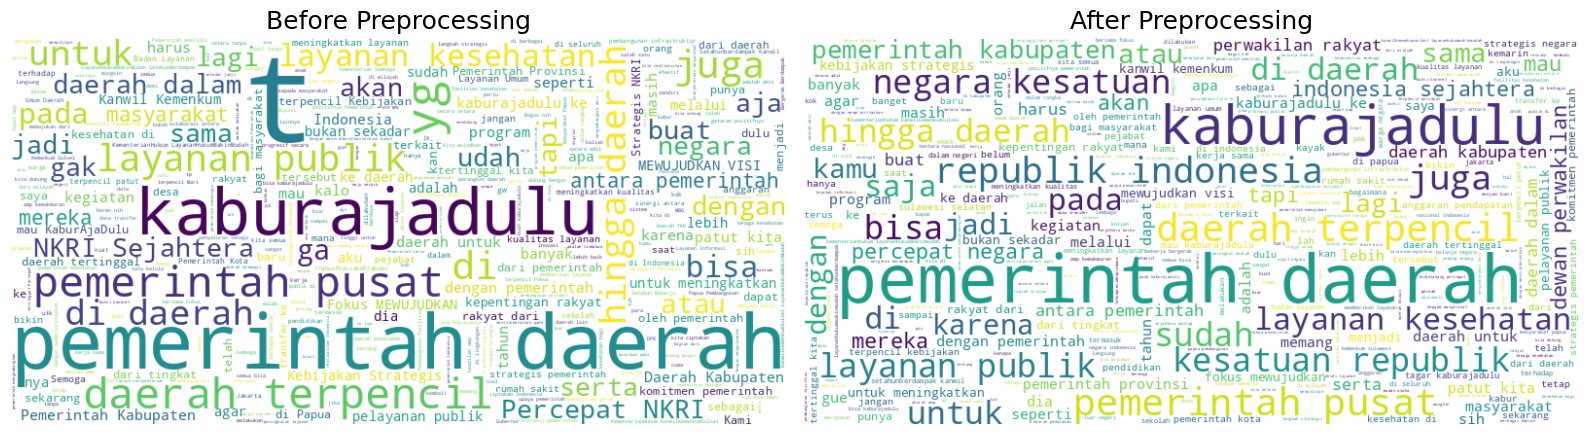

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau'])

# WordCloud before (dari kolom 'Review Text')
text_before = ' '.join(
    df['full_text']
    .astype(str)
    .tolist()
)

wc_before = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text_before)

# WordCloud after (dari kolom 'stopword removal')
text_after = ' '.join(
    [" ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
     for x in df['tokenize'].astype(str)]
)

wc_after = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text_after)

# visualisasi side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()


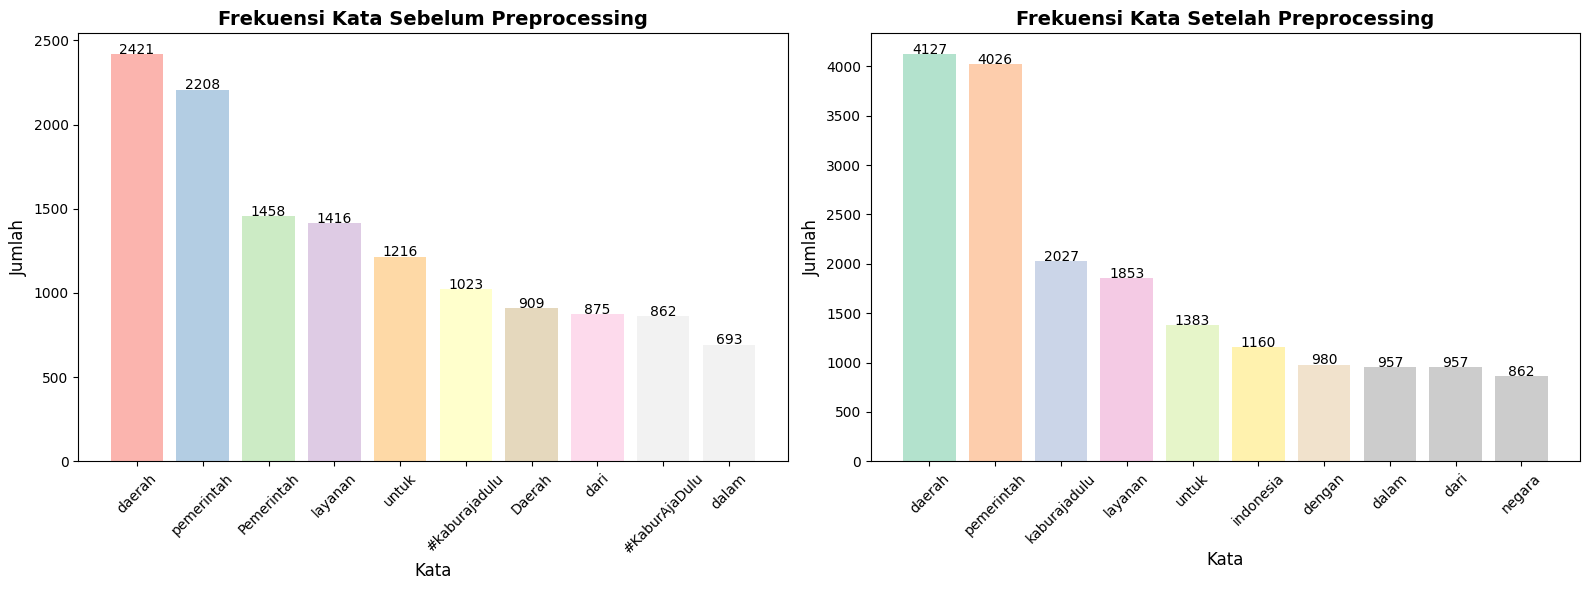

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'di', 'jadi'])

# fungsi helper untuk membersihkan tanda kutip, [ ], , dll
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        # Hapus [ ], tanda petik tunggal/ganda, koma
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE: kolom
all_text_before = clean_text_column(df["full_text"])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# AFTER: kolom
all_text_after = clean_text_column(df["tokenize"])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE Plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

# AFTER Plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
import ast

def convert_to_single_string(item):
    if isinstance(item, list):
        return ' '.join(item)
    elif isinstance(item, str):
        try:
            potential_list = ast.literal_eval(item)
            if isinstance(potential_list, list):
                return ' '.join(potential_list)
        except (ValueError, SyntaxError):
            pass
        return item
    return str(item)

df['tokenize'] = df['tokenize'].apply(convert_to_single_string)
df.to_csv('final_preprocessed_data.csv', index=False, encoding='utf-8')
print("DataFrame berhasil disimpan ke 'final_preprocessed_data.csv' dengan kolom 'tokenize' yang sudah digabungkan.")

DataFrame berhasil disimpan ke 'final_preprocessed_data.csv' dengan kolom 'tokenize' yang sudah digabungkan.


In [ ]:
df

,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dan dewan perwakilan rakyat ...,pemerintah daerah dan dewan perwakilan rakyat ...,"[pemerintah, daerah, dewan, perwakilan, rakyat...",perintah daerah dan dewan wakil rakyat daerah ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,Indonesia merdeka setelah perjuangan panjang m...,indonesia merdeka pada setelah perjuangan panj...,"[indonesia, merdeka, perjuangan, melawan, bela...",indonesia merdeka pada telah juang panjang law...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...","Apakah seperti yang dikatakan Pak Jokowidodo, ...",jika seperti kata bapak jokowidodo ini apakah ...,"[jokowidodo, pemerintah, daerah, menanggung, r...",jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,Pemkot Bekasi dan Pemkab Bekasi menyatakan kes...,pemerintah kota bekasi maupun pemerintah kabup...,"[pemerintah, kota, bekasi, pemerintah, kabupat...",perintah kota bekas maupun perintah kabupaten ...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...","Pak Purbaya ya Menkeu, isinya saya lihat bagi ...",pak purbaya ya menteri keuangan isinya saya li...,"[purbaya, ya, menteri, keuangan, isinya, lihat...",pak purbaya ya menteri uang isi saya lihat sha...
...,...,...,...,...,...,...,...,...,...,...,...
5708,2022-06-03,08:32:12,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,ketua fraksi gerindra dprd kabupaten kotawarin...,ketua fraksi gerindra dewan perwakilan rakyat ...,Chairman of the Gerindra faction of the Region...,Chairman of the Gerindra faction of the Region...,ketua fraksi gerindra dewan perwakilan rakyat ...,"[ketua, fraksi, gerindra, dewan, perwakilan, r...",ketua fraksi gerindra dewan wakil rakyat daera...
5709,2022-06-03,05:01:54,Halo sobat Miso pada Hari Jumat 03 Juni 2022 K...,Halo sobat Miso pada Hari Jumat Juni Kantor Im...,halo sobat miso pada hari jumat juni kantor im...,halo sobat miso pada hari jumat juni kantor im...,"hello miso friends, on Friday June the Sorong ...","hello miso friends, on Friday June the Sorong ...",halo sobat miso pada hari jumat juni kantor im...,"[halo, sobat, miso, jumat, juni, kantor, imigr...",halo sobat miso pada hari jumat juni kantor im...
5710,2022-06-03,03:41:36,ASABRI bekerja sama dengan TASPEN Pemerintah D...,ASABRI bekerja sama dengan TASPEN Pemerintah D...,asabri bekerja sama dengan taspen pemerintah d...,asabri bekerja sama dengan taspen pemerintah d...,"Asabri collaborates with Taspen, the regional ...","Asabri collaborates with Taspen, the regional ...",asabri bekerja sama dengan taspen pemerintah d...,"[asabri, taspen, pemerintah, daerah, kota, tas...",asabri kerja sama dengan taspen perintah daera...
5711,202

# ***PROSES ANALISIS***

**IMPORT DEPENDENCIES**

In [ ]:
import os
import glob
import numpy as np
import joblib
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path


from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm, naive_bayes
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from transformers import pipeline, AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from datetime import datetime

**LOAD DATA**

In [ ]:
# path ke file csv (pastikan nama file sama)
INPUT_CSV = "/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/final_preprocessed_data_pemda.csv"

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['tokenize']).reset_index(drop=True)

print("Jumlah baris (setelah dropna tokenize):", len(df))
df.head()


Jumlah baris (setelah dropna tokenize): 5713


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...


In [ ]:
print("Jumlah data sebelum hapus duplikasi:", len(df))

# hapus data yang duplikat
df = df.drop_duplicates(subset=["tokenize"], keep="first").reset_index(drop=True)

print("Jumlah data setelah hapus duplikasi:", len(df))

df

Jumlah data sebelum hapus duplikasi: 5713
Jumlah data setelah hapus duplikasi: 5451


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...
...,...,...,...,...,...,...,...,...,...,...,...
5446,2022-06-04,20:48:35,Pelatihan ini merupakan upaya Kementerian @kem...,Pelatihan ini merupakan upaya Kementerian untu...,pelatihan ini merupakan upaya kementerian untu...,pelatihan ini merupakan upaya kementerian untu...,This training is the ministry's effort to enco...,pelatihan merupakan upaya kementerian mendoron...,pelatihan ini merupakan upaya kementerian untu...,"['pelatihan', 'upaya', 'kementerian', 'mendoro...",latih ini rupa upaya menteri untuk dorong manf...
5447,2022-06-03,08:32:12,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,Ketua Fraksi Gerindra DPRD Kabupaten Kotawarin...,ketua fraksi gerindra dprd kabupaten kotawarin...,ketua fraksi gerindra dewan perwakilan rakyat ...,Chairman of the Gerindra faction of the Region...,ketua fraksi gerindra dprd kabupaten kotawarin...,ketua fraksi gerindra dewan perwakilan rakyat ...,"['ketua', 'fraksi', 'gerindra', 'dewan', 'perw...",ketua fraksi gerindra dewan wakil rakyat daera...
5448,2022-06-03,05:01:54,Halo sobat Miso pada Hari Jumat 03 Juni 2022 K...,Halo sobat Miso pada Hari Jumat Juni Kantor Im...,halo sobat miso pada hari jumat juni kantor im...,halo sobat miso pada hari jumat juni kantor im...,"hello miso friends, on Friday June the Sorong ...",halo sobat miso hari jumat bulan juni pihak im...,halo sobat miso pada hari jumat juni kantor im...,"['halo', 'sobat', 'miso', 'jumat', 'juni', 'ka...",halo sobat miso pada hari jumat juni kantor im...
5449,2022-06-03,03

# ANALISIS SENTIMEN MENGGUNAKAN INDOBERT

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
# setup
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 1. perbaikan nama model (hapus '-01')
SENT_MODEL = "w11wo/indonesian-roberta-base-sentiment-classifier"

print(f" Loading model: {SENT_MODEL} ...")

try:
    # device: -1 = CPU, 0 = GPU (pastikan runtime GPU aktif biar cepat)
    sentiment_model = pipeline(
        "sentiment-analysis",
        model=SENT_MODEL,
        tokenizer=SENT_MODEL,
        device=0,
        truncation=True,
        max_length=512     # RoBERTa support sampai 512 token
    )
    print("Model siap dan berhasil dimuat!")
except Exception as e:
    print(f" Error loading model: {e}")
    print("Saran: Coba restart runtime (Runtime > Restart Session) lalu jalankan lagi.")

save_path = "output_batches_roberta"
os.makedirs(save_path, exist_ok=True)

# 2. ganti kolom input
# gunakan 'translated_text' (hasil translate) atau 'cleaning' (jika tidak ada translate)
TEXT_COLUMN = "tokenize"

# cek kolom
if TEXT_COLUMN not in df.columns:
    print(f" Kolom '{TEXT_COLUMN}' tidak ditemukan! Menggunakan 'cleaning' sebagai alternatif.")
    TEXT_COLUMN = "cleaning"

print(f" Menggunakan kolom teks: {TEXT_COLUMN}")

# pastikan string & tidak NaN
df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str)

n = len(df)
loop_batch_size = 200     # potongan DataFrame
pipe_batch_size = 32      # Batch internal GPU

def run_pipeline_on_texts(text_list):
    """Jalankan pipeline. Model w11wo outputnya langsung: positive, neutral, negative."""
    is_empty = [(t.strip() == "") for t in text_list]
    safe_texts = [("." if e else t) for t, e in zip(text_list, is_empty)] # titik lebih aman drpd spasi utk RoBERTa

    try:
        results = sentiment_model(
            safe_texts,
            batch_size=pipe_batch_size,
            truncation=True
        )
        # ambil label langsung (positive/negative/neutral)
        labels = [r["label"] for r in results]
    except Exception as e:
        print("Batch pipeline error:", e)
        labels = ["neutral"] * len(text_list) # fallback ke neutral jika error

    # handle text kosong jadi neutral
    labels = [("neutral" if empty else lab) for empty, lab in zip(is_empty, labels)]
    return labels

 Loading model: w11wo/indonesian-roberta-base-sentiment-classifier ...


Device set to use cuda:0


Model siap dan berhasil dimuat!
 Menggunakan kolom teks: tokenize


In [ ]:
# fungsi normlisasi label
def normalize_label(label):
    """
    Ubah output model (lowercase) menjadi Title Case agar rapi di grafik.
    negative -> Negative
    neutral  -> Neutral
    positive -> Positive
    """
    if pd.isna(label):
        return "Neutral"
    return str(label).capitalize() # cukup dikapitalisasi

In [ ]:
# proses per-batch & simpan
print("Memulai Analisis Sentimen...")

for start in tqdm(range(0, n, loop_batch_size), desc="Processing batches"):
    end = min(start + loop_batch_size, n)
    filename = f"{save_path}/batch_{start}_{end-1}.csv"

    # resume capability
    if os.path.exists(filename):
        try:
            _tmp = pd.read_csv(filename)
            if len(_tmp) == (end - start):
                continue
        except Exception:
            pass

    batch_df = df.iloc[start:end].copy()
    texts = batch_df[TEXT_COLUMN].tolist()

    # jalankan Model
    raw_labels = run_pipeline_on_texts(texts)

    batch_df["Sentiment_Raw"] = raw_labels
    # normalisasi label (positive -> Positive)
    batch_df["Sentiment_Label"] = [normalize_label(lab) for lab in raw_labels]

    batch_df.to_csv(filename, index=False)

print("Semua batch selesai diproses.")

Memulai Analisis Sentimen...


Processing batches:   0%|          | 0/28 [00:00<?, ?it/s]

Semua batch selesai diproses.


In [ ]:
# gabungkan se4mua batch
all_parts = sorted(glob.glob(f"{save_path}/batch_*.csv"))
final_df = pd.concat((pd.read_csv(p) for p in all_parts), ignore_index=True)

# simpan hasil akhir
final_df.to_csv("hasil_sentiment_roberta_final_steming_data.csv", index=False)
print("File tersimpan: hasil_sentiment_roberta_final.csv")

File tersimpan: hasil_sentiment_roberta_final.csv


In [ ]:
# 1. hitung data
order = ["Negative", "Neutral", "Positive"]
counts = final_df["Sentiment_Label"].value_counts().reindex(order).fillna(0).astype(int)
perc   = (counts / counts.sum() * 100).round(2)

print("\n=== Distribusi Sentimen (RoBERTa) ===")
display(pd.DataFrame({"Count": counts, "Percent (%)": perc}))


=== Distribusi Sentimen (RoBERTa) ===


,Count,Percent (%)
Sentiment_Label,,
Negative,1830,33.57
Neutral,2535,46.51
Positive,1086,19.92


Grafik berhasil disimpan: revisi_chart_sentimen_20251220_052100.png


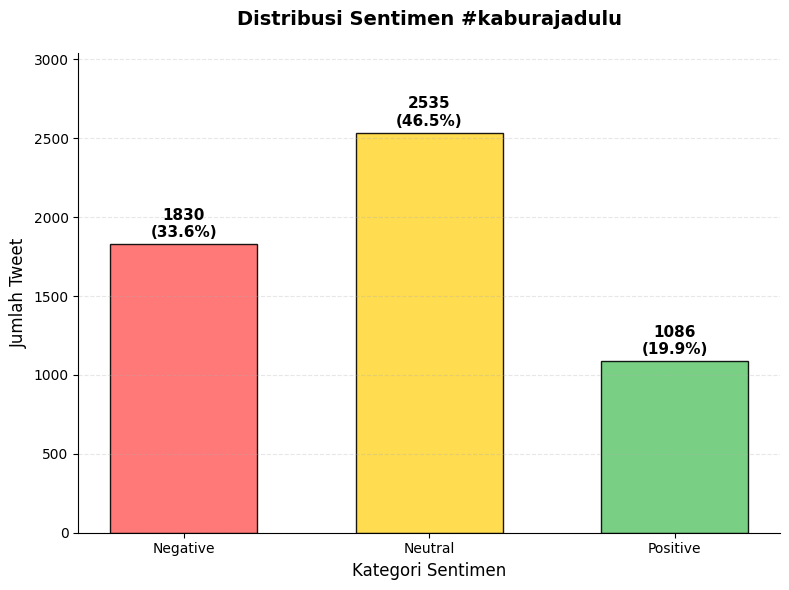

In [ ]:
# setup plot
plt.figure(figsize=(8, 6))

colors = {
    "Negative": "#FF6B6B",
    "Neutral": "#FFD93D",
    "Positive": "#6BCB77"
}

# membuat bar chart
bars = plt.bar(
    counts.index,
    counts.values,
    color=[colors.get(x, "#CCCCCC") for x in counts.index],
    edgecolor="black",
    alpha=0.9,
    width=0.6  # mengatur lebar batang biar proporsional
)

# ambil nilai tertinggi dari data
max_y = counts.max()
# set batas atas grafik jadi 120% dari nilai tertinggi (memberi ruang napas 20%)
plt.ylim(0, max_y * 1.2)

# menambahkan label angka di atas batang
for bar, count, pct in zip(bars, counts.values, perc.values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,      # Posisi X (Tengah)
        height + (max_y * 0.01),              # Posisi Y (Sedikit di atas batang)
        f"{int(count)}\n({pct:.1f}%)",        # Teks
        ha='center', va='bottom',             # Alignment
        fontsize=11, fontweight='bold', color='black'
    )

# dekorasi grafik
plt.title("Distribusi Sentimen #kaburajadulu", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Kategori Sentimen", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# menghilangkan garis kotak atas dan kanan agar lebih bersih
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# simpan gambar
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f"revisi_chart_sentimen_{ts}.png"
plt.savefig(filename, dpi=300)

print(f"Grafik berhasil disimpan: {filename}")
plt.show()

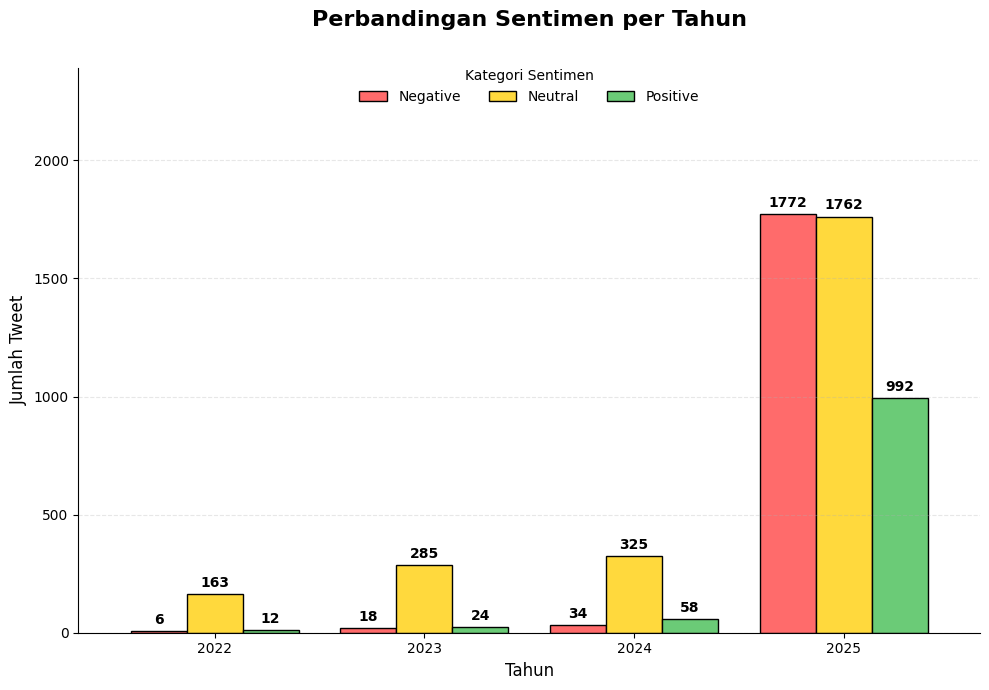

In [ ]:
# 1. pastikan data siap (final_df harus ada)
final_df['tanggal'] = pd.to_datetime(final_df['tanggal'], errors='coerce')
final_df['Tahun'] = final_df['tanggal'].dt.year

# 2. buat tabel pivot
yearly_counts = pd.crosstab(final_df['Tahun'], final_df['Sentiment_Label'])
order = ["Negative", "Neutral", "Positive"]
yearly_counts = yearly_counts.reindex(columns=order, fill_value=0)

# 3. setup plot
plt.figure(figsize=(10, 7)) # sedikit dipertinggi agar muat

colors = ["#FF6B6B", "#FFD93D", "#6BCB77"]

ax = yearly_counts.plot(
    kind='bar',
    color=colors,
    figsize=(10, 7),
    edgecolor='black',
    width=0.8,
    ax=plt.gca()
)

# 4. atur batas atas (beri ruang lebih luas di atas batang)
max_y = yearly_counts.max().max()
plt.ylim(0, max_y * 1.35) # naikkan 35% biar legend muat di dalam

# 5. label angka
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='edge',
        padding=3,
        fontsize=10,
        fontweight='bold'
    )

# PERBAIKAN POSISI JUDUL & LEGEND

# naikkan judul agar jauh dari grafik
plt.title("Perbandingan Sentimen per Tahun", fontsize=16, fontweight='bold', pad=30)
# pad=30 artinya judul didorong ke atas sejauh 30 poin

# atur legend agar pas di bawah judul tapi tidak menabrak
plt.legend(
    title="Kategori Sentimen",
    loc='upper center',         # Titik jangkar di tengah atas
    bbox_to_anchor=(0.5, 1.02), # (X=Tengah, Y=Sedikit di atas garis grafik)
    ncol=3,                     # Dijajar ke samping (3 kolom)
    frameon=False               # Hilangkan kotak garis legend agar bersih
)

# 6. dekorasi lain
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# hapus garis border atas/kanan
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

# simpan
plt.savefig("revisi_sentimen_pertahun.png", dpi=300)
plt.show()

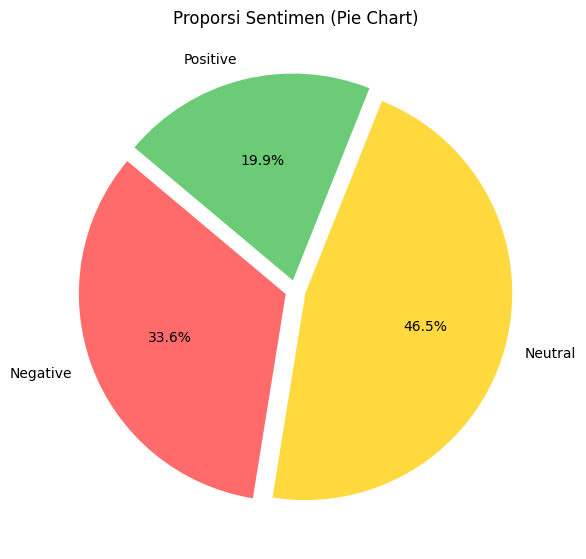

In [ ]:
# plot pie chart
plt.figure(figsize=(6, 6))

colors = {
    "Negative": "#FF6B6B",
    "Neutral": "#FFD93D",
    "Positive": "#6BCB77"
}

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    colors=[colors.get(x, "#CCCCCC") for x in counts.index], # efek pecahan sedikit
    explode=(0.05, 0.05, 0.05)
)
plt.title("Proporsi Sentimen (Pie Chart)")
plt.ylabel("")
plt.tight_layout()
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
plt.savefig(f"roberta_distribution_pie_{ts}.png", dpi=300)
plt.show()

# ***WORDCLOUD***



In [ ]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/hasil_sentiment_kaburajadulu_roberta_final_steming_data.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5451 non-null   object
 1   waktu             5451 non-null   object
 2   full_text         5451 non-null   object
 3   cleaning          5451 non-null   object
 4   case_folding      5451 non-null   object
 5   normalisasi       5451 non-null   object
 6   text_english      5451 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5451 non-null   object
 9   stopword removal  5451 non-null   object
 10  steming_data      5451 non-null   object
 11  Sentiment_Raw     5451 non-null   object
 12  Sentiment_Label   5451 non-null   object
dtypes: object(13)
memory usage: 553.7+ KB


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data,Sentiment_Raw,Sentiment_Label
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...,neutral,Neutral
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...,negative,Negative
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...,negative,Negative
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...,neutral,Neutral
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...,negative,Negative


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5449 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5449 non-null   object
 1   waktu             5449 non-null   object
 2   full_text         5449 non-null   object
 3   cleaning          5449 non-null   object
 4   case_folding      5449 non-null   object
 5   normalisasi       5449 non-null   object
 6   text_english      5449 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5449 non-null   object
 9   stopword removal  5449 non-null   object
 10  steming_data      5449 non-null   object
 11  Sentiment_Raw     5449 non-null   object
 12  Sentiment_Label   5449 non-null   object
dtypes: object(13)
memory usage: 596.0+ KB


In [ ]:
data = pd.DataFrame(data[['tokenize','Sentiment_Label']])
data.head(5)

,tokenize,Sentiment_Label
0,pemerintah daerah dan dewan perwakilan rakyat ...,Neutral
1,indonesia merdeka pada setelah perjuangan panj...,Negative
2,jika seperti kata bapak jokowidodo ini apakah ...,Negative
3,pemerintah kota bekasi maupun pemerintah kabup...,Neutral
4,pak purbaya ya menteri keuangan isinya saya li...,Negative


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment_Label'] == 'Neutral']['tokenize'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment_Label'] == 'Negative']['tokenize'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment_Label'] == 'Positive']['tokenize'].str.cat(sep=' ')

# buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'ketua', 'psi', 'kaesang', 'prabowo', 'badan', 'usaha', 'milik', 'negara', 'ganjar', 'pranowo', 'asmara', 'tayang', 'jam', 'sctv', 'calon', 'wakil', 'presiden'])
# Buat wordcloud untuk masing-masing sentimen
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(sentimen_Neutral)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds', stopwords=stopwords).generate(sentimen_Negative)
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='Greens', stopwords=stopwords).generate(sentimen_Positive)

# fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


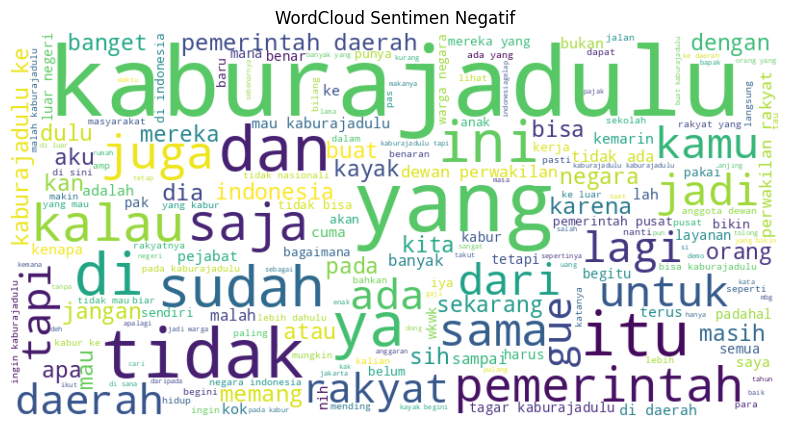

In [ ]:
# membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

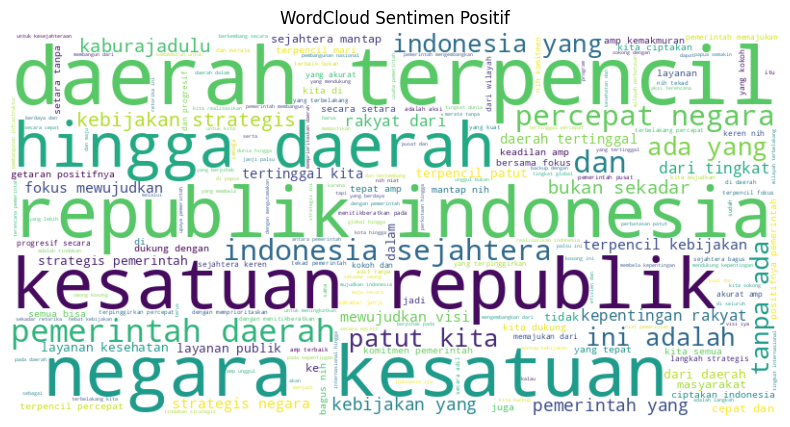

In [ ]:
# membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

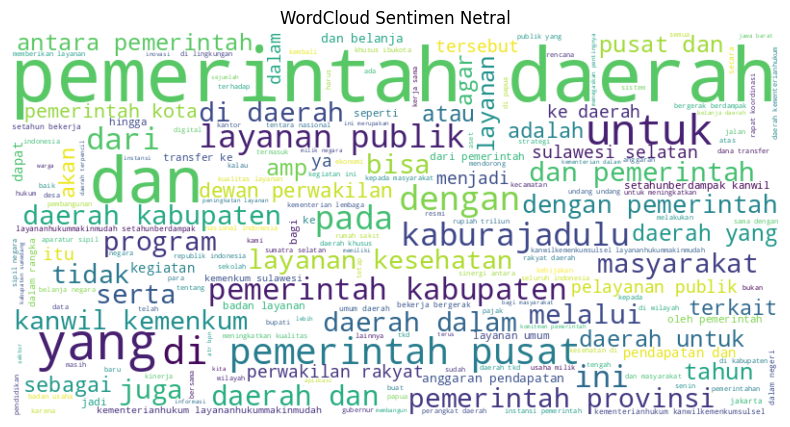

In [ ]:
# membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

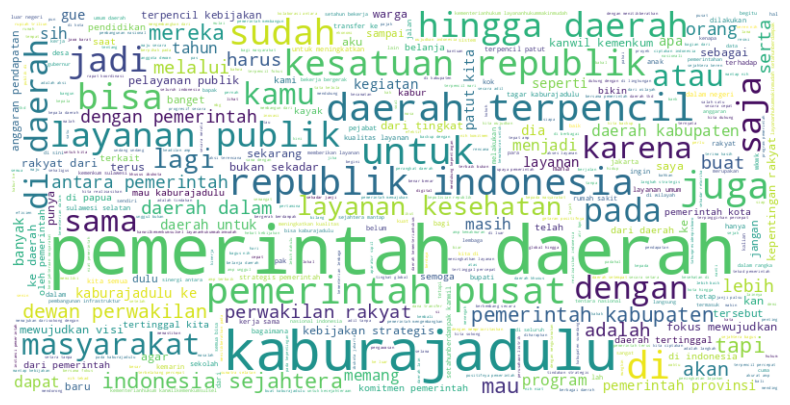

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# mengisi nilai NaN dengan string kosong ('')
data['tokenize'] = data['tokenize'].fillna('')

# menggabungkan teks dari kolom
text = ' '.join(data['tokenize'].astype(str).tolist())

# buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'ketua', 'psi', 'kaesang', 'prabowo', 'badan', 'usaha', 'milik', 'negara', 'ganjar', 'pranowo', 'asmara', 'tayang', 'jam', 'sctv', 'calon', 'wakil', 'presiden'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=1000, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# ***FREKUENSI KATA***



In [ ]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/hasil_sentiment_kaburajadulu_roberta_final_steming_data.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5451 non-null   object
 1   waktu             5451 non-null   object
 2   full_text         5451 non-null   object
 3   cleaning          5451 non-null   object
 4   case_folding      5451 non-null   object
 5   normalisasi       5451 non-null   object
 6   text_english      5451 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5451 non-null   object
 9   stopword removal  5451 non-null   object
 10  steming_data      5451 non-null   object
 11  Sentiment_Raw     5451 non-null   object
 12  Sentiment_Label   5451 non-null   object
dtypes: object(13)
memory usage: 553.7+ KB


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data,Sentiment_Raw,Sentiment_Label
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...,neutral,Neutral
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...,negative,Negative
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...,negative,Negative
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...,neutral,Neutral
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...,negative,Negative


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5449 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5449 non-null   object
 1   waktu             5449 non-null   object
 2   full_text         5449 non-null   object
 3   cleaning          5449 non-null   object
 4   case_folding      5449 non-null   object
 5   normalisasi       5449 non-null   object
 6   text_english      5449 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5449 non-null   object
 9   stopword removal  5449 non-null   object
 10  steming_data      5449 non-null   object
 11  Sentiment_Raw     5449 non-null   object
 12  Sentiment_Label   5449 non-null   object
dtypes: object(13)
memory usage: 596.0+ KB


In [ ]:
data = pd.DataFrame(data[['tokenize','Sentiment_Label']])
data.head(5)

,tokenize,Sentiment_Label
0,pemerintah daerah dan dewan perwakilan rakyat ...,Neutral
1,indonesia merdeka pada setelah perjuangan panj...,Negative
2,jika seperti kata bapak jokowidodo ini apakah ...,Negative
3,pemerintah kota bekasi maupun pemerintah kabup...,Neutral
4,pak purbaya ya menteri keuangan isinya saya li...,Negative


In [ ]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

# pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment_Label'] == 'Neutral']['tokenize'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment_Label'] == 'Negative']['tokenize'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment_Label'] == 'Positive']['tokenize'].str.cat(sep=' ')

# buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'ketua', 'psi', 'kaesang', 'prabowo', 'badan', 'usaha', 'milik', 'negara', 'ganjar', 'pranowo', 'asmara', 'tayang', 'jam', 'sctv', 'calon', 'wakil', 'presiden'])

# fungsi hitung frekuensi kata + tampilkan jumlah
def plot_word_freq(text, title, color):
    words = [w for w in text.split() if w not in stopwords]
    word_freq = Counter(words).most_common(10)  # ambil 10 kata teratas
    df_freq = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(8,5))
    bars = plt.barh(df_freq['Kata'], df_freq['Frekuensi'], color=color)
    plt.gca().invert_yaxis()  # biar kata frekuensi tertinggi di atas
    plt.title(f"Top 10 Kata - Sentimen {title}", fontsize=14)
    plt.xlabel("Frekuensi")
    plt.ylabel("Kata")

    # tambahkan label jumlah di ujung bar
    for bar in bars:
        plt.text(
            bar.get_width() + 0.2,  # posisi X sedikit ke kanan
            bar.get_y() + bar.get_height()/2,  # posisi Y di tengah bar
            str(int(bar.get_width())),  # nilai frekuensi
            va='center'
        )

    plt.show()

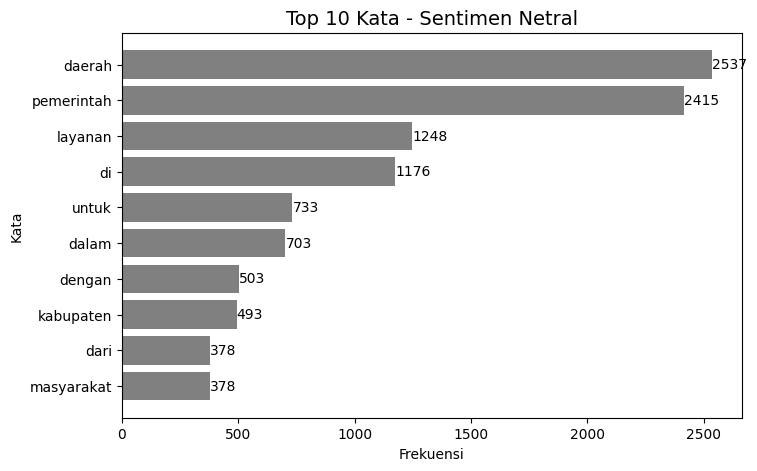

In [ ]:
plot_word_freq(sentimen_Neutral, "Netral", "gray")

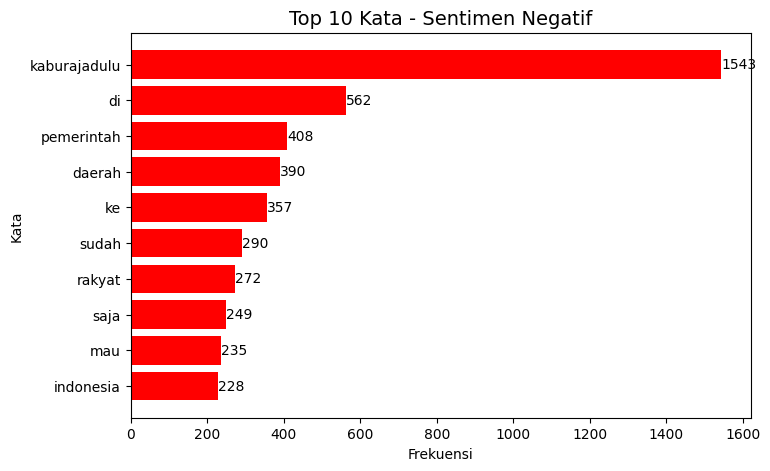

In [ ]:
plot_word_freq(sentimen_Negative, "Negatif", "red")

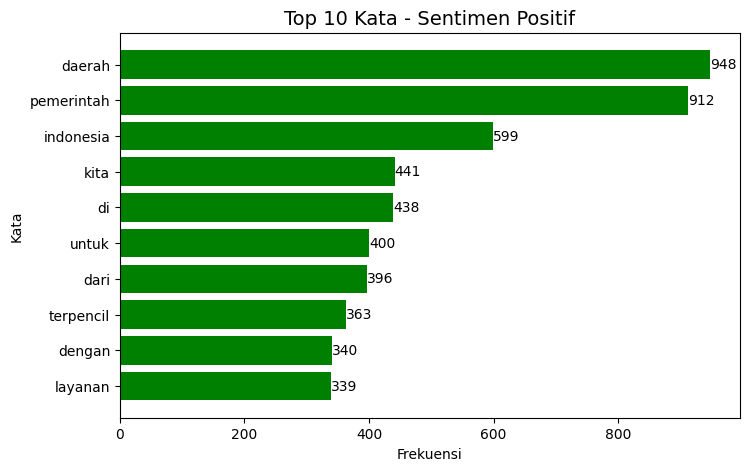

In [ ]:
plot_word_freq(sentimen_Positive, "Positif", "green")

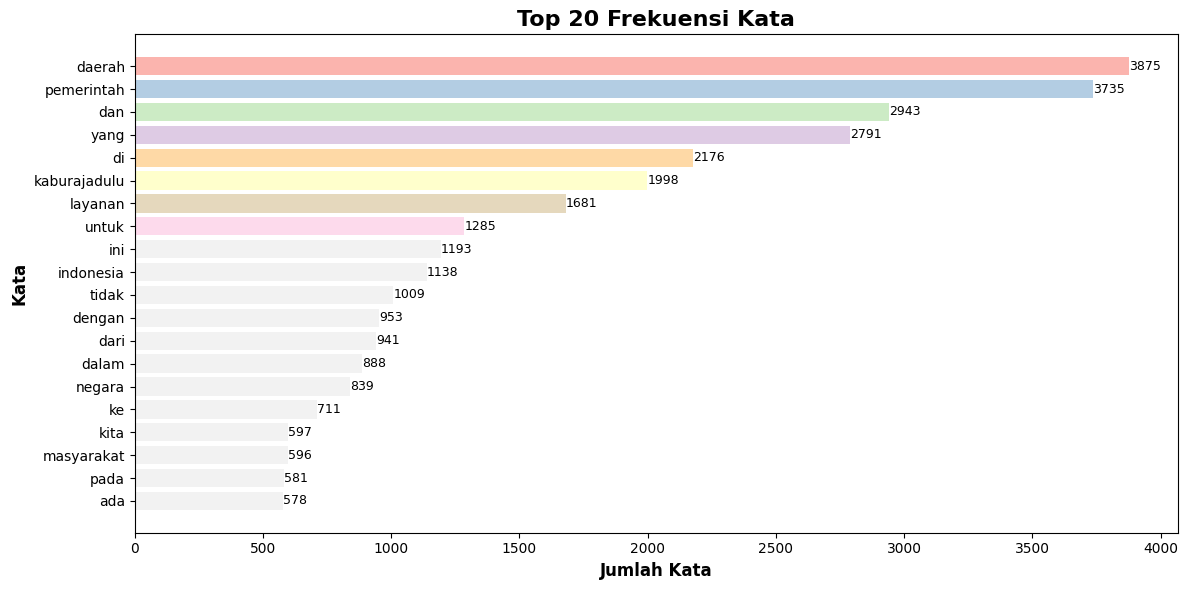

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# gabungkan semua teks
text = " ".join(data["tokenize"])

tokens = text.split()
word_counts = Counter(tokens)

# ambil 20 kata teratas
top_words = word_counts.most_common(20)
word, count = zip(*top_words)

# palet warna soft (Pastel)
colors = plt.cm.Pastel1(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.barh(word, count, color=colors)
plt.xlabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.ylabel("Kata", fontsize=12, fontweight='bold')
plt.title("Top 20 Frekuensi Kata", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # biar frekuensi tertinggi di atas

# tambahkan angka di ujung bar
for bar, num in zip(bars, count):
    plt.text(num + 0.5, bar.get_y() + bar.get_height()/2,
             str(num), va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


# ***N-Gram Frekuensi Kata***



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/hasil_sentiment_kaburajadulu_roberta_final_steming_data.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5451 non-null   object
 1   waktu             5451 non-null   object
 2   full_text         5451 non-null   object
 3   cleaning          5451 non-null   object
 4   case_folding      5451 non-null   object
 5   normalisasi       5451 non-null   object
 6   text_english      5451 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5451 non-null   object
 9   stopword removal  5451 non-null   object
 10  steming_data      5451 non-null   object
 11  Sentiment_Raw     5451 non-null   object
 12  Sentiment_Label   5451 non-null   object
dtypes: object(13)
memory usage: 553.7+ KB


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data,Sentiment_Raw,Sentiment_Label
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...,neutral,Neutral
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...,negative,Negative
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...,negative,Negative
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...,neutral,Neutral
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...,negative,Negative


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5449 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5449 non-null   object
 1   waktu             5449 non-null   object
 2   full_text         5449 non-null   object
 3   cleaning          5449 non-null   object
 4   case_folding      5449 non-null   object
 5   normalisasi       5449 non-null   object
 6   text_english      5449 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5449 non-null   object
 9   stopword removal  5449 non-null   object
 10  steming_data      5449 non-null   object
 11  Sentiment_Raw     5449 non-null   object
 12  Sentiment_Label   5449 non-null   object
dtypes: object(13)
memory usage: 596.0+ KB


In [ ]:
data = pd.DataFrame(data[['tokenize','Sentiment_Label']])
data.head(5)

,tokenize,Sentiment_Label
0,pemerintah daerah dan dewan perwakilan rakyat ...,Neutral
1,indonesia merdeka pada setelah perjuangan panj...,Negative
2,jika seperti kata bapak jokowidodo ini apakah ...,Negative
3,pemerintah kota bekasi maupun pemerintah kabup...,Neutral
4,pak purbaya ya menteri keuangan isinya saya li...,Negative


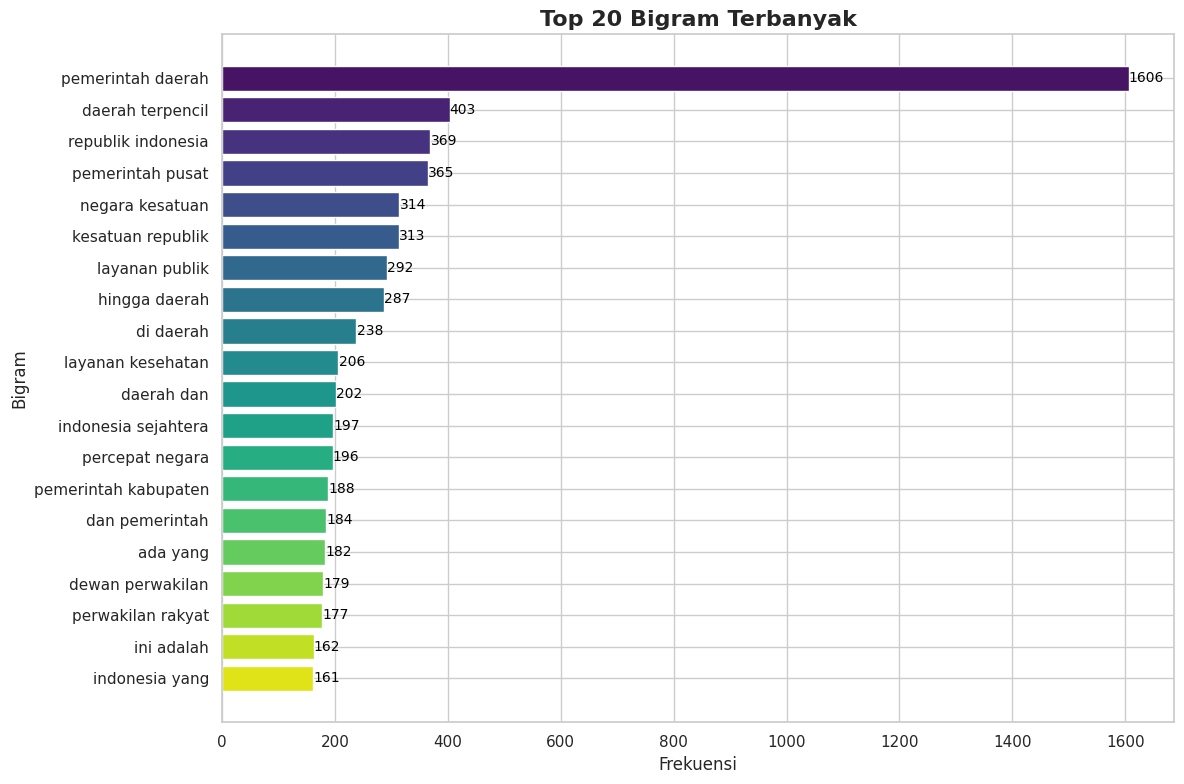

In [ ]:
# Bigram Calculation
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2))
X_bigram = bigram_vectorizer.fit_transform(data['tokenize'])

bigram_counts = X_bigram.sum(axis=0).A1
bigram_vocab = bigram_vectorizer.get_feature_names_out()

bigram_freq = list(zip(bigram_vocab, bigram_counts))
bigram_freq_sorted = sorted(bigram_freq, key=lambda x: x[1], reverse=True)[:20]

bigrams, counts = zip(*bigram_freq_sorted)

# Visualization
plt.figure(figsize=(12, 8))

sns.set(style="whitegrid")

# Membuat palet warna gradien
colors = sns.color_palette("viridis", len(bigrams))

# Horizontal bar chart
plt.barh(bigrams, counts, color=colors)

# Memberi anotasi nilai frekuensi
for i, v in enumerate(counts):
    plt.text(v + 0.2, i, str(v), color='black', va='center', fontsize=10)

plt.gca().invert_yaxis()  # Bigram terbanyak muncul di atas
plt.title("Top 20 Bigram Terbanyak", fontsize=16, weight='bold')
plt.xlabel("Frekuensi", fontsize=12)
plt.ylabel("Bigram", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# stopwords tambahan (bisa disesuaikan)
# daftar stopwords tambahan
custom_stopwords = set
custom_stopwords = ['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'ketua', 'psi', 'kaesang', 'prabowo', 'badan', 'usaha', 'milik', 'negara', 'ganjar', 'pranowo', 'asmara', 'tayang', 'jam', 'sctv', 'calon', 'wakil', 'presiden', 'prabowotulus']



# fungsi buat ambil n-gram
def get_top_ngrams(corpus, n=10, top_k=10, stopwords=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# fungsi buat plot frekuensi n-gram
def plot_ngrams(corpus, sentiment_label, color_map=plt.cm.Set2, stopwords=None):
    top_ngrams = get_top_ngrams(corpus, n=3, top_k=7, stopwords=stopwords)
    if not top_ngrams:
        print(f"Tidak ada trigram untuk sentimen {sentiment_label}")
        return

    ngrams, counts = zip(*top_ngrams)
    colors = color_map(range(len(ngrams)))

    plt.figure(figsize=(10,6))
    bars = plt.barh(ngrams, counts, color=colors)
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Trigram - Sentimen {sentiment_label}", fontsize=16, fontweight='bold')
    plt.xlabel("Jumlah Kemunculan", fontsize=12)
    plt.ylabel("Trigram", fontsize=12)

    # tambahin label jumlah di ujung bar
    for bar, num in zip(bars, counts):
        plt.text(num + 0.01, bar.get_y() + bar.get_height()/2,
                 str(num), va='center', fontsize=11, color='black')

    plt.tight_layout()
    plt.show()


# ambil data per sentimen
corpus_negatif = data[data['Sentiment_Label'] == 'Negative']['tokenize'].astype(str).tolist()
corpus_netral = data[data['Sentiment_Label'] == 'Neutral']['tokenize'].astype(str).tolist()
corpus_positif = data[data['Sentiment_Label'] == 'Positive']['tokenize'].astype(str).tolist()

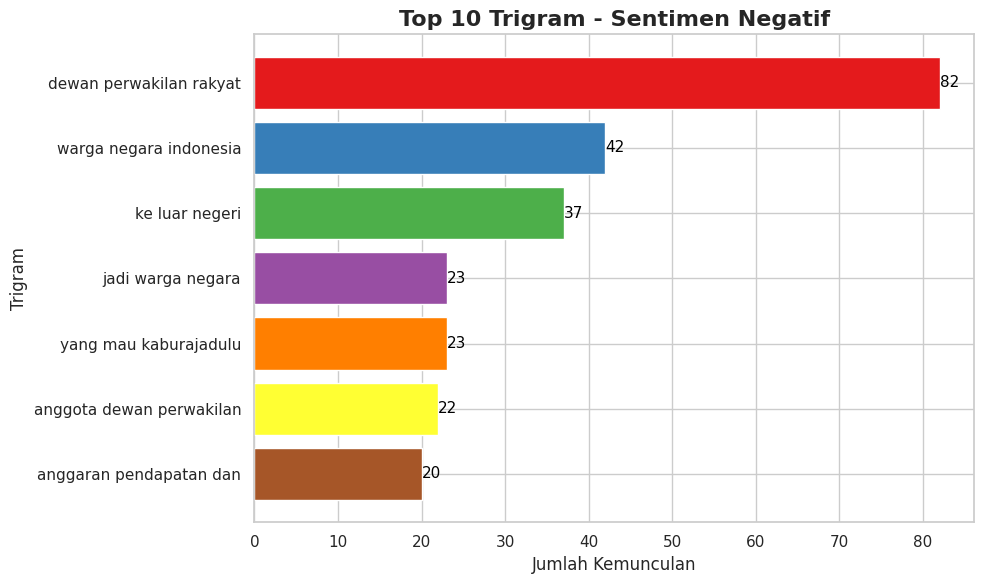

In [ ]:
plot_ngrams(corpus_negatif, "Negatif", plt.cm.Set1)

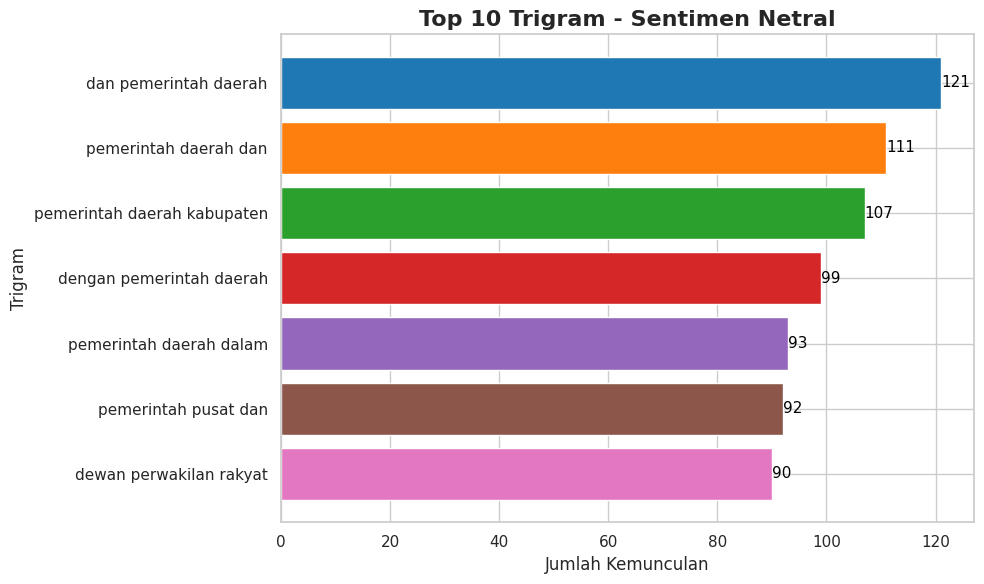

In [ ]:
plot_ngrams(corpus_netral, "Netral", plt.cm.tab10)

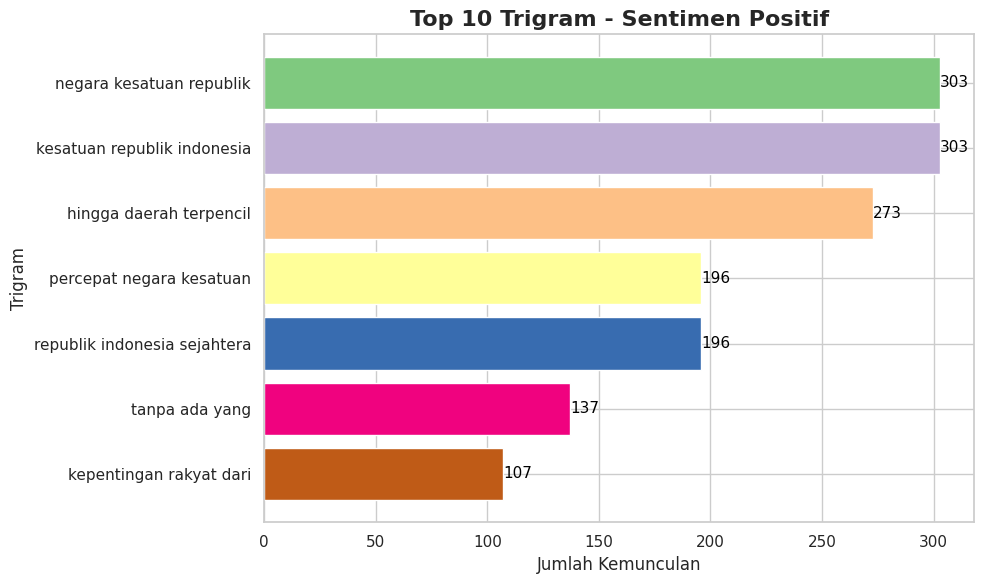

In [ ]:
plot_ngrams(corpus_positif, "Positif", plt.cm.Accent)

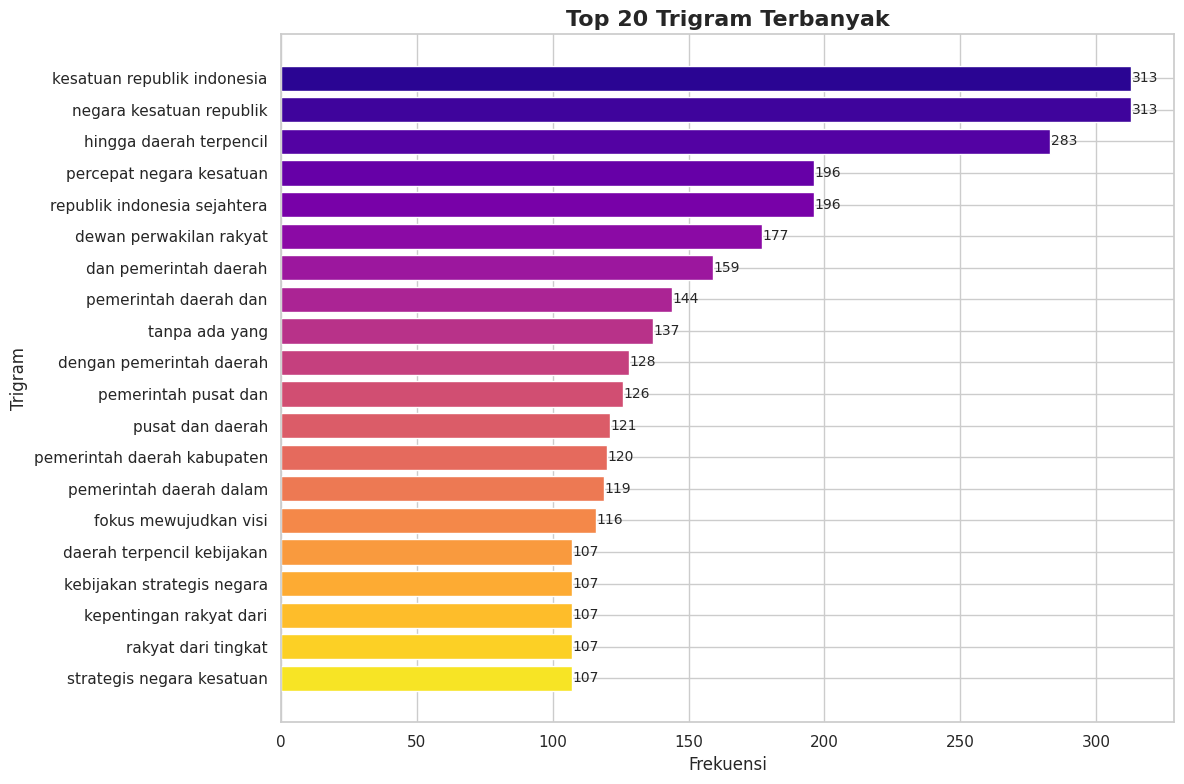

In [ ]:
# Trigram Keseluruhan

# Trigram Calculation
trigram_vectorizer = CountVectorizer(ngram_range=(3,3))
X_trigram = trigram_vectorizer.fit_transform(data['tokenize'])

trigram_counts = X_trigram.sum(axis=0).A1
trigram_vocab = trigram_vectorizer.get_feature_names_out()

trigram_freq = list(zip(trigram_vocab, trigram_counts))
trigram_freq_sorted = sorted(trigram_freq, key=lambda x: x[1], reverse=True)[:20]

trigrams, counts = zip(*trigram_freq_sorted)

# Visualization
plt.figure(figsize=(12, 8))

sns.set(style="whitegrid")

# Color palette (gradien)
colors = sns.color_palette("plasma", len(trigrams))

# Horizontal bar plot
plt.barh(trigrams, counts, color=colors)

# Anotasi nilai frekuensi
for i, v in enumerate(counts):
    plt.text(v + 0.2, i, str(v), va='center', fontsize=10)

plt.gca().invert_yaxis()  # paling besar di atas
plt.title("Top 20 Trigram Terbanyak", fontsize=16, weight='bold')
plt.xlabel("Frekuensi", fontsize=12)
plt.ylabel("Trigram", fontsize=12)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['amp', 'rt'] not in stop_words.
  warnings.warn(


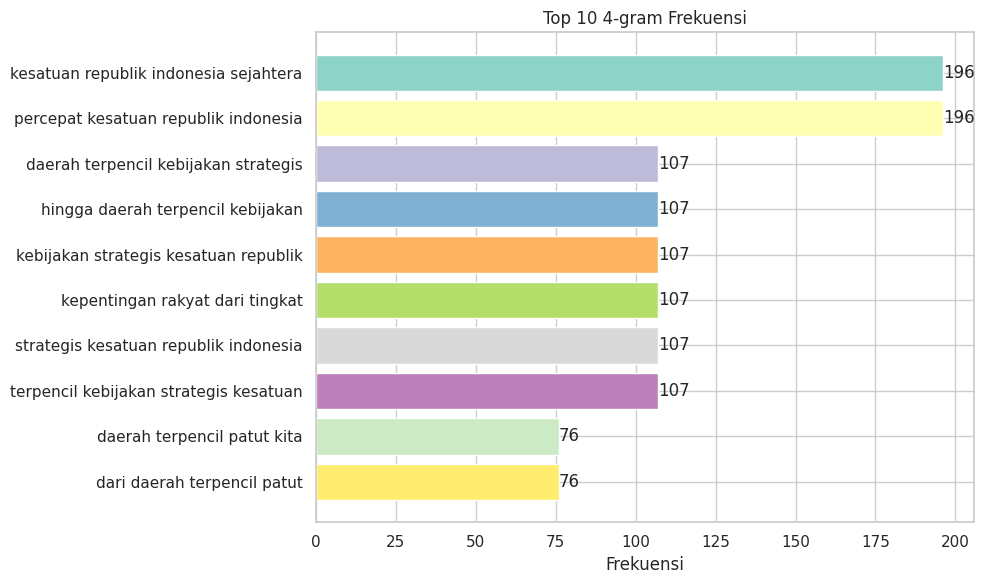

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# daftar stopwords tambahan
custom_stopwords = set(ENGLISH_STOP_WORDS)
custom_stopwords = ['https', '@', 'co', 'RT', '...', 'amp;', 'lu', 'deh', 'ini', 'itu', 'ya', 'yang', 'tidak', 'dan', 'ada', 'kalau', 'ketua', 'psi', 'kaesang', 'prabowo', 'badan', 'usaha', 'milik', 'negara', 'ganjar', 'pranowo', 'asmara', 'tayang', 'jam', 'sctv', 'calon', 'wakil', 'presiden']

# fungsi untuk membuat diagram batang frekuensi n-gram
def plot_ngram_frequencies(texts, ngram_range=(4,4), top_n=10, cmap=plt.cm.Set3):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=custom_stopwords)
    X = vectorizer.fit_transform(texts)

    # hitung total frekuensi setiap n-gram
    ngram_counts = X.sum(axis=0).A1
    ngram_vocab = vectorizer.get_feature_names_out()
    freq_dist = dict(zip(ngram_vocab, ngram_counts))

    # ambil n-gram dengan frekuensi tertinggi
    top_ngrams = Counter(freq_dist).most_common(top_n)
    labels, values = zip(*top_ngrams)

    # buat warna berbeda untuk tiap bar
    colors = cmap(np.linspace(0, 1, len(labels)))

    # visualisasi
    plt.figure(figsize=(10, 6))
    bars = plt.barh(labels[::-1], values[::-1], color=colors[::-1])
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Frekuensi')
    plt.xlabel('Frekuensi')

    # tambahkan label angka di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width}', va='center')

    plt.tight_layout()
    plt.show()

# contoh pemanggilan: visualisasi 4-gram
plot_ngram_frequencies(data['tokenize'], ngram_range=(4,4), top_n=10, cmap=plt.cm.Set3)

# TF-IDF + Evaluasi NBC, SVM, Random forest with sentimen roberta/indobert

In [ ]:
!pip install -q scikit-learn joblib


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/hasil_sentiment_kaburajadulu_roberta_final_steming_data.csv")
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5451 entries, 0 to 5450
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   tanggal           5451 non-null   object
 1   waktu             5451 non-null   object
 2   full_text         5451 non-null   object
 3   cleaning          5451 non-null   object
 4   case_folding      5451 non-null   object
 5   normalisasi       5451 non-null   object
 6   text_english      5451 non-null   object
 7   translated_text   5449 non-null   object
 8   tokenize          5451 non-null   object
 9   stopword removal  5451 non-null   object
 10  steming_data      5451 non-null   object
 11  Sentiment_Raw     5451 non-null   object
 12  Sentiment_Label   5451 non-null   object
dtypes: object(13)
memory usage: 553.7+ KB


,tanggal,waktu,full_text,cleaning,case_folding,normalisasi,text_english,translated_text,tokenize,stopword removal,steming_data,Sentiment_Raw,Sentiment_Label
0,2025-10-18,23:23:24,@salam4jari Pemerintah Daerah dan DPRD sebagai...,Pemerintah Daerah dan DPRD sebagai lingkup ter...,pemerintah daerah dan dprd sebagai lingkup ter...,pemerintah daerah dan dewan perwakilan rakyat ...,regional governments and regional people's rep...,pemerintah daerah dewan perwakilan rakyat daer...,pemerintah daerah dan dewan perwakilan rakyat ...,"['pemerintah', 'daerah', 'dewan', 'perwakilan'...",perintah daerah dan dewan wakil rakyat daerah ...,neutral,Neutral
1,2025-10-18,23:23:14,@mahdimdm_ @TirtoID Indonesia merdeka pada 194...,Indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,indonesia merdeka pada setelah perjuangan panj...,Indonesia became independent after a long stru...,indonesia merdeka perjuangan panjang melawan b...,indonesia merdeka pada setelah perjuangan panj...,"['indonesia', 'merdeka', 'perjuangan', 'melawa...",indonesia merdeka pada telah juang panjang law...,negative,Negative
2,2025-10-18,22:36:22,Jika seperti kata bapak Jokowidodo ini apakah ...,Jika seperti kata bapak Jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,jika seperti kata bapak jokowidodo ini apakah ...,"If, as Mr. Jokowidodo said, is the regional go...",dikatakan pak jokowidodo pemerintah daerah sia...,jika seperti kata bapak jokowidodo ini apakah ...,"['jokowidodo', 'pemerintah', 'daerah', 'menang...",jika seperti kata bapak jokowidodo ini apakah ...,negative,Negative
3,2025-10-18,22:11:12,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,Pemerintah Kota Bekasi maupun Pemerintah Kabup...,pemerintah kota bekasi maupun pemerintah kabup...,pemerintah kota bekasi maupun pemerintah kabup...,The Bekasi City Government and the Bekasi Rege...,pemkot bekasi pemkab bekasi menyatakan kesiapa...,pemerintah kota bekasi maupun pemerintah kabup...,"['pemerintah', 'kota', 'bekasi', 'pemerintah',...",perintah kota bekas maupun perintah kabupaten ...,neutral,Neutral
4,2025-10-18,19:22:10,Pak purbaya ya menteri keuangan Isinya saya li...,Pak purbaya ya menteri keuangan Isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,pak purbaya ya menteri keuangan isinya saya li...,"Mr. Purbaya, yes, Minister of Finance, the con...",pak purbaya menkeu isinya lihat hasil bobrok p...,pak purbaya ya menteri keuangan isinya saya li...,"['purbaya', 'ya', 'menteri', 'keuangan', 'isin...",pak purbaya ya menteri uang isi saya lihat sha...,negative,Negative


# Import & Konfigurasi

In [ ]:
#  TF-IDF + Evaluasi NBC, SVM, Random Forest
#  (tanpa data leakage, timing komputasi)

# Part 1 — Import & Konfigurasi

# Import modul dasar sistem & utilitas umum
import os          # Untuk manajemen file & folder
import time        # Untuk menghitung waktu eksekusi (timing)
import numpy as np # Library numerik untuk perhitungan array/matriks
import matplotlib.pyplot as plt # Untuk visualisasi data
import pandas as pd # Untuk memproses data dalam bentuk tabel (DataFrame)
import seaborn as sns # Untuk visualisasi data yang menarik dan informatif
from pathlib import Path # Untuk mempermudah manipulasi path/direktori


# Import modul dari scikit-learn untuk pemrosesan data & model ML
from sklearn.model_selection import train_test_split  # Membagi data menjadi train & test
from sklearn.preprocessing import LabelEncoder        # Mengubah label kategori menjadi angka

# Import metrik evaluasi model
from sklearn.metrics import (
    accuracy_score,          # Akurasi: proporsi prediksi yang benar
    precision_score,         # Presisi: fokus pada seberapa banyak prediksi positif yang benar
    recall_score,            # Recall: fokus pada seberapa banyak kasus positif yang berhasil terdeteksi
    f1_score,                # F1-score: rata-rata harmonis antara presisi dan recall
    classification_report,   # Laporan lengkap per metrik untuk tiap kelas
    confusion_matrix         # Matriks perbandingan antara label aktual dan prediksi
)

# Import TF-IDF Vectorizer untuk mengubah teks menjadi representasi numerik
from sklearn.feature_extraction.text import TfidfVectorizer

# Import algoritma machine learning yang digunakan
from sklearn.naive_bayes import MultinomialNB        # Model probabilistik untuk teks
from sklearn.svm import LinearSVC                    # Support Vector Machine dengan kernel linear
from sklearn.ensemble import RandomForestClassifier  # Ensemble model berbasis pohon keputusan

# Library tambahan untuk menyimpan model
import joblib  # Untuk menyimpan dan memuat model hasil training ke/dari file

# Konfigurasi Awal

RANDOM_STATE = 42  # Nilai seed random agar hasil eksperimen konsisten

# Menentukan kolom teks dan label dari dataset
TEXT_COLUMN  = "tokenize"     # Nama kolom berisi data teks yang akan diproses
LABEL_COLUMN = "Sentiment_Label"  # Nama kolom label sentimen (Negative/Neutral/Positive)

Part 2 — Load data terlabel

In [ ]:
# Part 2 — Load & Persiapan Data

# Mengecek apakah variabel 'stemming_data' sudah ada di memori
if 'tokenize' not in globals():
    # Jika belum ada, maka lanjutkan untuk memuat file CSV

    # Menentukan path atau lokasi file dataset
    # Ganti nama file jika nama file CSV kamu berbeda
    final_path = "/content/drive/MyDrive/Analisis Sentimen Gen Z terhadap Layanan Administrasi Pemerintah Daerah dalam Fenomena #kaburajadulu/hasil_sentiment_kaburajadulu_roberta_final_steming_data.csv"

    # Memeriksa apakah file tersebut ada di direktori kerja
    # Jika tidak ada, tampilkan pesan

    # Mengecek apakah file tersebut benar-benar ada di direktori kerja
    # Jika tidak ada, tampilkan pesan error
    assert Path(final_path).exists(), f"File tidak ditemukan: {final_path}"

    # Membaca file CSV menggunakan pandas dan menyimpannya ke variabel 'final_df'
    final_df = pd.read_csv(final_path)

# Membuat salinan dari dataframe utama untuk keamanan
# (agar data asli tidak berubah saat kita lakukan preprocessing)
data = final_df.copy()

# Mengisi nilai kosong (NaN) di kolom teks dengan string kosong ""
# lalu memastikan semua data bertipe string (str)
data[TEXT_COLUMN] = data[TEXT_COLUMN].fillna("").astype(str)

# Membersihkan kolom label dengan memastikan bertipe string dan menghapus spasi di awal/akhir
data[LABEL_COLUMN] = data[LABEL_COLUMN].astype(str).str.strip()

# Filter Data: Menjaga hanya data yang valid

# Menentukan label yang dianggap valid (harus sesuai dengan tiga kategori ini)
valid_labels = {"Negative", "Neutral", "Positive"}

# Menyaring data agar hanya menyisakan baris dengan label yang valid
data = data[data[LABEL_COLUMN].isin(valid_labels)]

# Menyaring data agar teks tidak kosong (string kosong dibuang)
data = data[data[TEXT_COLUMN].str.strip() != ""].reset_index(drop=True)

# Output Informasi Awal

# Menampilkan jumlah data yang lolos seleksi dan siap digunakan
print("Jumlah data siap:", len(data))

# Menampilkan 5 baris pertama dari kolom teks dan label
data[[TEXT_COLUMN, LABEL_COLUMN]].head()


Jumlah data siap: 5451


,tokenize,Sentiment_Label
0,pemerintah daerah dan dewan perwakilan rakyat ...,Neutral
1,indonesia merdeka pada setelah perjuangan panj...,Negative
2,jika seperti kata bapak jokowidodo ini apakah ...,Negative
3,pemerintah kota bekasi maupun pemerintah kabup...,Neutral
4,pak purbaya ya menteri keuangan isinya saya li...,Negative


Part 3 — Train/Test Split (tanpa leakage)


>>> Menggunakan rasio Train–Test: 80:20 (test_size=0.2)

=== Ringkasan Pembagian Data ===
    Data  Jumlah Sampel  Persentase
0  Train           4360   79.985324
1   Test           1091   20.014676


/tmp/ipython-input-2775074896.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=split_df, x="Data", y="Jumlah Sampel", palette=colors)


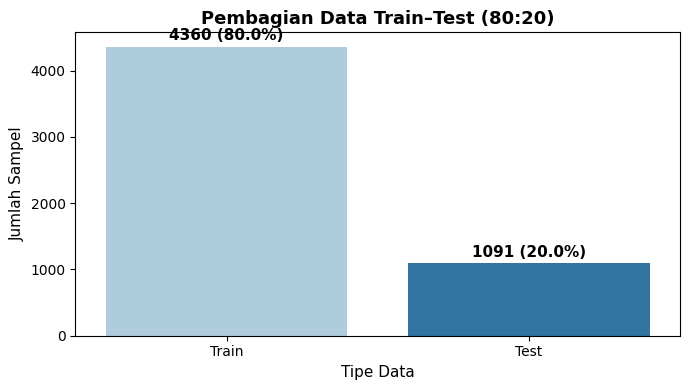


=== Distribusi Sentimen Data Train ===
          Count  Percentage
Neutral    2008       46.06
Negative   1460       33.49
Positive    892       20.46

=== Distribusi Sentimen Data Test ===
          Count  Percentage
Neutral     502       46.01
Negative    366       33.55
Positive    223       20.44


In [ ]:
# Part 3 — Data Split (Pembagian Data Train dan Test)

# Mengambil kolom teks dari dataset dan menyimpannya sebagai variabel fitur (X)
X = data[TEXT_COLUMN].values
# Mengambil kolom label sentimen dari dataset dan menyimpannya sebagai variabel target (y)
y = data[LABEL_COLUMN].values

# Label Encoding (Mengubah label menjadi angka)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)   # Misal: Negative=0, Neutral=1, Positive=2

# KONFIGURASI BEBERAPA RASIO TRAIN–TEST
split_configs = {
    "80:20": 0.20,   # 20% test → 80% train
    "75:25": 0.25,   # 25% test → 75% train
    "70:30": 0.30,    # 30% test → 70% train
    "90:10": 0.10    # 10% test → 90% train
}

# PILIH RASIO YANG MAU DICOBA
# Tinggal ganti string ini: "80:20" / "75:25" / "70:30"
CURRENT_SPLIT = "80:20"   # <= ganti di sini kalau mau coba rasio lain

test_size_value = split_configs[CURRENT_SPLIT]
print(f"\n>>> Menggunakan rasio Train–Test: {CURRENT_SPLIT} (test_size={test_size_value})")

# Membagi Data Menjadi Train dan Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=test_size_value,
    stratify=y_enc,
    random_state=RANDOM_STATE
)

# Menghitung Jumlah & Persentase Data
train_count = len(X_train)
test_count  = len(X_test)
total       = train_count + test_count

train_pct = train_count / total * 100
test_pct  = test_count  / total * 100

split_df = pd.DataFrame({
    "Data": ["Train", "Test"],
    "Jumlah Sampel": [train_count, test_count],
    "Persentase": [train_pct, test_pct]
})

print("\n=== Ringkasan Pembagian Data ===")
print(split_df)

# Visualisasi Pembagian Data
plt.figure(figsize=(7, 4))
colors = ["#a6cee3", "#1f78b4"]
ax = sns.barplot(data=split_df, x="Data", y="Jumlah Sampel", palette=colors)

for i, row in split_df.iterrows():
    ax.text(
        i,
        row["Jumlah Sampel"] + total * 0.01,
        f"{int(row['Jumlah Sampel'])} ({row['Persentase']:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.title(f"Pembagian Data Train–Test ({CURRENT_SPLIT})", fontsize=13, fontweight="bold")
plt.xlabel("Tipe Data", fontsize=11)
plt.ylabel("Jumlah Sampel", fontsize=11)
plt.tight_layout()
plt.show()

# Distribusi Sentimen di Data Train dan Test
print("\n=== Distribusi Sentimen Data Train ===")
train_labels = le.inverse_transform(y_train)
train_sentiment_counts = (
    pd.Series(train_labels)
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)
print(pd.DataFrame({
    "Count": pd.Series(train_labels).value_counts(),
    "Percentage": train_sentiment_counts
}))

print("\n=== Distribusi Sentimen Data Test ===")
test_labels = le.inverse_transform(y_test)
test_sentiment_counts = (
    pd.Series(test_labels)
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)
print(pd.DataFrame({
    "Count": pd.Series(test_labels).value_counts(),
    "Percentage": test_sentiment_counts
}))

# TF-IDF (fit di train saja, transform test)

In [ ]:
# Konfigurasi Parameter TF-IDF

# Import library yang dibutuhkan
import pandas as pd
import time
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat dictionary berisi parameter untuk konfigurasi TF-IDF
tfidf_params = dict(
    lowercase=True,       # Semua teks diubah ke huruf kecil agar konsisten
    analyzer="word",      # Analisis berbasis kata (bukan karakter)
    ngram_range=(1,2),    # Gunakan unigram (1 kata) dan bigram (2 kata)
    min_df=2,             # Kata harus muncul minimal di 2 dokumen agar dianggap penting
    max_df=0.95,          # Abaikan kata yang muncul di lebih dari 95% dokumen
    max_features=50000,   # Batasi jumlah fitur maksimum agar tidak terlalu besar
    sublinear_tf=True,    # Terapkan skala log(1 + tf) agar kata frekuensinya besar tidak mendominasi
    norm="l2"             # Normalisasi panjang vektor (L2 normalization)
)

# Membuat objek TF-IDF Vectorizer dengan parameter di atas
vectorizer = TfidfVectorizer(**tfidf_params)

# Proses Fit dan Transform TF-IDF

# Catat waktu awal sebelum proses fit TF-IDF
t0 = time.perf_counter()

# FIT dilakukan hanya pada data training agar tidak terjadi data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)

# Catat waktu setelah proses fit selesai
t1 = time.perf_counter()

# Transformasi data testing dengan model TF-IDF yang sudah dilatih
X_test_tfidf = vectorizer.transform(X_test)

# Catat waktu setelah proses transform selesai
t2 = time.perf_counter()

# Informasi Hasil Transformasi

# Menampilkan waktu eksekusi fit dan transform
print(f"TF-IDF fit waktu   : {t1 - t0:0.3f}s")
print(f"TF-IDF transform   : {t2 - t1:0.3f}s")
print("shape train/test   :", X_train_tfidf.shape, X_test_tfidf.shape)

# Simpan hasil TF-IDF (versi aman & versi CSV) + tampilkan df

# Ambil nama fitur (kata) yang dipelajari oleh TF-IDF
feature_names = vectorizer.get_feature_names_out()   # array berisi nama kolom (fitur)

# Buat DataFrame TF-IDF dari X_train_tfidf
# PERINGATAN: .toarray() mengubah sparse matrix menjadi dense array sehingga bisa sangat besar
# Jika datasetmu besar, gunakan opsi penyimpanan sparse di bawah (joblib)
tfidf_dense = X_train_tfidf.toarray()  # ubah sparse -> dense (pastikan RAM cukup)

# Buat DataFrame dari array dense dengan kolom = fitur
tfidf_df = pd.DataFrame(tfidf_dense, columns=feature_names)  # setiap kolom = kata, nilai = bobot TF-IDF

# Tambahkan kolom label (nilai asli, bukan encoded)
# y_train adalah numpy.ndarray berisi label encoded (misal 0/1/2)
# Gunakan LabelEncoder `le` untuk mengembalikan label aslinya dengan inverse_transform
labels_original = le.inverse_transform(y_train)   # contoh -> ["Negative","Positive",...]
tfidf_df["label"] = labels_original               # tambahkan kolom label teks

# Simpan ke CSV (opsi mudah dibuka tapi bisa besar)
output_csv = "tfidf_train_output.csv"
tfidf_df.to_csv(output_csv, index=False, encoding="utf-8-sig")  # simpan CSV tanpa index
print(f" Hasil TF-IDF (dense) disimpan sebagai CSV: {output_csv}")

# # Tampilkan beberapa baris pertama DataFrame TF-IDF agar bisa dilihat
# # Batasi tampilan kolom agar tidak memenuhi layar, ubah sesuai kebutuhan
# pd.set_option("display.max_columns", 20)  # tampilkan sampai 20 kolom di output notebook
# display(tfidf_df.head(10))                # tampilkan 10 baris pertama

# Opsi alternatif (direkomendasikan untuk dataset besar)
# Simpan hasil TF-IDF dalam format sparse + fitur + label (lebih hemat memori)

# Simpan objek sparse TF-IDF (lebih efisien) beserta feature_names dan labels ke file joblib
sparse_save_path = "tfidf_train_sparse_package.joblib"
joblib.dump({
    "X_train_tfidf": X_train_tfidf,   # sparse matrix tetap sparse
    "feature_names": feature_names,   # array nama fitur
    "labels": labels_original         # label asli (text)
}, sparse_save_path, compress=3)      # compress=3 untuk ukuran file lebih kecil

print(f" Versi sparse TF-IDF disimpan sebagai joblib: {sparse_save_path}")

TF-IDF fit waktu   : 0.484s
TF-IDF transform   : 0.045s
shape train/test   : (4360, 14509) (1091, 14509)
 Hasil TF-IDF (dense) disimpan sebagai CSV: tfidf_train_output.csv
 Versi sparse TF-IDF disimpan sebagai joblib: tfidf_train_sparse_package.joblib


In [ ]:
# Analisis tambahan: Top Fitur Global & Per Kelas
# Tujuan: mengetahui kata/fitur TF-IDF mana yang paling penting

import numpy as np                     # Library numerik untuk komputasi cepat
import pandas as pd                    # Library untuk pengolahan data berbasis DataFrame

# Pastikan variabel tfidf_df & labels_original sudah ada
# tfidf_df = DataFrame hasil proses TF-IDF sebelumnya (fitur TF-IDF + label sentimen)
# Kolom "label" menyimpan kelas sentimen (Negative / Neutral / Positive)

# Hapus kolom 'label' agar bisa menghitung rata-rata bobot TF-IDF
tfidf_only = tfidf_df.drop(columns=["label"])   # Hanya ambil nilai TF-IDF tanpa kolom label


# Top 20 Fitur Global (paling berpengaruh di seluruh dokumen)

# Hitung rata-rata bobot TF-IDF setiap fitur di seluruh dokumen
# Semakin tinggi rata-rata TF-IDF, semakin sering dan penting fitur tersebut muncul
mean_tfidf = tfidf_only.mean(axis=0)

# Urutkan hasil dari nilai TF-IDF tertinggi ke terendah
top_global_features = mean_tfidf.sort_values(ascending=False).head(20)

# Tampilkan 20 fitur global teratas beserta bobot rata-ratanya dalam tabel berwarna
print("=== Top 20 Fitur Global (rata-rata TF-IDF tertinggi) ===")
display(top_global_features.to_frame(name="mean_TFIDF").style.background_gradient(cmap="YlGnBu"))
# → 'background_gradient' memberi warna visual gradasi agar fitur paling kuat mudah dikenali

# Top 20 Fitur per Kelas Sentimen
# Tujuan: mengetahui fitur unik dan dominan di setiap kategori sentimen

top_features_per_class = {}   # Buat dictionary kosong untuk menyimpan hasil tiap label

# Loop setiap label (Negative, Neutral, Positive)
for label in sorted(tfidf_df["label"].unique()):
    # Ambil subset baris yang memiliki label tertentu
    subset = tfidf_df[tfidf_df["label"] == label].drop(columns=["label"])

    # Hitung rata-rata bobot TF-IDF setiap fitur pada subset label tersebut
    mean_per_label = subset.mean(axis=0)

    # Urutkan fitur dari bobot tertinggi ke terendah dan ambil 20 teratas
    top20 = mean_per_label.sort_values(ascending=False).head(20)

    # Simpan hasil ke dictionary dengan nama label sebagai key
    top_features_per_class[label] = top20

# Tampilkan hasil untuk setiap kelas sentimen
for label, features in top_features_per_class.items():
    print(f"\n=== Top 20 Fitur untuk Kelas: {label} ===")
    # Tampilkan tabel warna dengan nilai TF-IDF tertinggi ditandai
    display(features.to_frame(name="mean_TFIDF").style.background_gradient(cmap="YlOrRd"))

# Simpan hasil analisis top fitur ke CSV

# Ubah hasil global menjadi DataFrame agar bisa digabung dengan hasil per kelas
global_df = top_global_features.reset_index()      # Reset index agar kolom fitur jadi kolom biasa
global_df.columns = ["fitur", "mean_TFIDF"]        # Ganti nama kolom agar lebih deskriptif
global_df["kelas"] = "GLOBAL"                      # Tambahkan kolom 'kelas' untuk menandai hasil global

# Gabungkan semua hasil per kelas ke dalam satu DataFrame besar
per_class_df = pd.concat([
    pd.DataFrame({
        "fitur": feats.index,                      # Nama fitur (kata)
        "mean_TFIDF": feats.values,                # Nilai rata-rata TF-IDF
        "kelas": label                             # Nama label sentimen
    })
    for label, feats in top_features_per_class.items()
])

# Gabungkan hasil global dan per kelas menjadi satu tabel besar
final_top_features_df = pd.concat([global_df, per_class_df], ignore_index=True)

# Simpan hasil analisis ke file CSV agar bisa dibuka di Excel atau visualisasi lain
top_features_path = "top_tfidf_features.csv"
final_top_features_df.to_csv(top_features_path, index=False, encoding="utf-8-sig")

# Konfirmasi bahwa file sudah tersimpan
print(f"\n Hasil top fitur (global & per kelas) disimpan ke: {top_features_path}")


=== Top 20 Fitur Global (rata-rata TF-IDF tertinggi) ===


,mean_TFIDF
kaburajadulu,0.037198
daerah,0.027250
pemerintah,0.026649
yang,0.025965
dan,0.024256
di,0.021523
pemerintah daerah,0.018143
layanan,0.018010
ini,0.015717
untuk,0.015707



=== Top 20 Fitur untuk Kelas: Negative ===


,mean_TFIDF
kaburajadulu,0.086431
tidak,0.033547
yang,0.031258
sudah,0.020635
ya,0.020540
ke,0.020017
itu,0.018251
mau,0.017590
di,0.017459
mereka,0.017103



=== Top 20 Fitur untuk Kelas: Neutral ===


,mean_TFIDF
daerah,0.039190
pemerintah,0.037934
pemerintah daerah,0.031077
dan,0.030831
layanan,0.029023
di,0.025050
dalam,0.019998
untuk,0.019422
yang,0.017689
kabupaten,0.015982



=== Top 20 Fitur untuk Kelas: Positive ===


,mean_TFIDF
yang,0.035934
indonesia,0.034291
dan,0.032379
daerah,0.031914
kita,0.031022
pemerintah,0.030719
daerah terpencil,0.028888
terpencil,0.028836
kesatuan,0.026288
republik indonesia,0.026090



 Hasil top fitur (global & per kelas) disimpan ke: top_tfidf_features.csv


# Helper evaluasi + timing

In [ ]:
# Fungsi untuk mengevaluasi model klasifikasi berbasis TF-IDF
def evaluate_model(name, clf, Xtr, ytr, Xte, yte, params_used=None, save_dir="clf_reports"):
    os.makedirs(save_dir, exist_ok=True)                      # Membuat folder "clf_reports" jika belum ada

    # Proses Training (fit)
    t0 = time.perf_counter()                                  # Mulai stopwatch untuk menghitung waktu training
    clf.fit(Xtr, ytr)                                         # Latih model dengan data train (fit)
    t1 = time.perf_counter()                                  # Catat waktu setelah proses training selesai

    # Proses Prediksi (infer)
    t2 = time.perf_counter()                                  # Mulai stopwatch sebelum prediksi
    y_pred = clf.predict(Xte)                                 # Model melakukan prediksi pada data test
    t3 = time.perf_counter()                                  # Catat waktu setelah proses prediksi selesai

    # Hitung metrik evaluasi
    acc  = accuracy_score(yte, y_pred)                        # Hitung akurasi
    prec = precision_score(yte, y_pred, average="macro", zero_division=0)  # Hitung presisi rata-rata (macro)
    rec  = recall_score(yte, y_pred, average="macro", zero_division=0)     # Hitung recall rata-rata (macro)
    f1   = f1_score(yte, y_pred, average="macro", zero_division=0)         # Hitung F1-score rata-rata (macro)
    report = classification_report(                           # Buat laporan klasifikasi (per kelas)
        yte, y_pred, target_names=le.classes_, digits=4, zero_division=0
    )
    cm = confusion_matrix(yte, y_pred)                        # Hitung confusion matrix

    # Tampilkan hasil di console
    print(f"\n=== {name} ===")                               # Cetak nama model
    print(f"Train time (s): {t1 - t0:0.3f}")                  # Tampilkan waktu training
    print(f"Infer  time (s): {t3 - t2:0.3f}")                 # Tampilkan waktu inferensi
    print(f"Accuracy : {acc:0.4f}")                           # Tampilkan akurasi
    print(f"Precision(macro) : {prec:0.4f} | Recall(macro): {rec:0.4f} | F1(macro): {f1:0.4f}")  # Presisi, recall, F1
    print("\nClassification report:\n", report)               # Cetak laporan klasifikasi
    print("Confusion matrix (rows=true, cols=pred):\n", cm)   # Cetak confusion matrix mentah

    # Visualisasi confusion matrix
    plt.figure(figsize=(6,5))                                 # Tentukan ukuran plot 6x5 inci
    sns.heatmap(                                              # Gunakan seaborn heatmap untuk membuat visualisasi
        cm,                                                   # Data confusion matrix
        annot=True, fmt="d", cmap="Blues",                    # Tampilkan angka, format integer, warna biru
        xticklabels=le.classes_, yticklabels=le.classes_      # Label sumbu X dan Y berdasarkan nama kelas
    )
    plt.title(f"Confusion Matrix - {name} (TF-IDF)")          # Judul grafik
    plt.xlabel("Predicted")                                   # Label sumbu X
    plt.ylabel("Actual")                                      # Label sumbu Y
    plt.tight_layout()                                        # Rapikan tata letak
    plt.savefig(                                              # Simpan gambar heatmap ke folder laporan
        Path(save_dir) / f"{name}_confusion_matrix.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()                                                # Tampilkan grafik di notebook

    # Simpan hasil evaluasi ke file txt
    rep_path = Path(save_dir) / f"{name}_report.txt"          # Tentukan lokasi file teks hasil laporan
    with open(rep_path, "w", encoding="utf-8") as f:          # Buka file dengan mode tulis (write)
        f.write(f"{name} | params={params_used}\n\n")         # Tulis nama model dan parameter yang digunakan
        f.write(f"Train time (s): {t1 - t0:0.4f}\n")          # Waktu training
        f.write(f"Infer  time (s): {t3 - t2:0.4f}\n")         # Waktu inferensi
        f.write(f"Accuracy      : {acc:0.4f}\n")              # Akurasi
        f.write(f"Precision(m)  : {prec:0.4f}\n")             # Presisi
        f.write(f"Recall(m)     : {rec:0.4f}\n")              # Recall
        f.write(f"F1-macro      : {f1:0.4f}\n\n")             # F1 score
        f.write(report)                                       # Tambahkan laporan klasifikasi lengkap
        f.write("\nConfusion matrix:\n")                      # Tulis label sebelum matriks
        f.write(np.array2string(cm))                          # Konversi matriks ke string agar bisa disimpan

    # Simpan model terlatih
    joblib.dump(clf, f"{name}_model.joblib")                  # Simpan model ke file joblib agar bisa digunakan lagi

    # Kembalikan ringkasan hasil evaluasi
    return {
        "Model": name,                                        # Nama model (misal: "SVC" atau "NaiveBayes")
        "Params": params_used,                                # Parameter model yang digunakan
        "Train_time_s": round(t1 - t0, 4),                    # Lama training dalam detik
        "Infer_time_s": round(t3 - t2, 4),                    # Lama inferensi dalam detik
        "Accuracy": round(acc, 4),                            # Akurasi model
        "Precision_macro": round(prec, 4),                    # Nilai presisi macro
        "Recall_macro": round(rec, 4),                        # Nilai recall macro
        "F1_macro": round(f1, 4)                              # Nilai F1 macro
    }


=== MultinomialNB(Baseline) ===
Train time (s): 0.007
Infer  time (s): 0.001
Accuracy : 0.8011
Precision(macro) : 0.7980 | Recall(macro): 0.7661 | F1(macro): 0.7718

Classification report:
               precision    recall  f1-score   support

    Negative     0.7668    0.9344    0.8424       366
     Neutral     0.8350    0.8167    0.8258       502
    Positive     0.7922    0.5471    0.6472       223

    accuracy                         0.8011      1091
   macro avg     0.7980    0.7661    0.7718      1091
weighted avg     0.8034    0.8011    0.7948      1091

Confusion matrix (rows=true, cols=pred):
 [[342  20   4]
 [ 64 410  28]
 [ 40  61 122]]


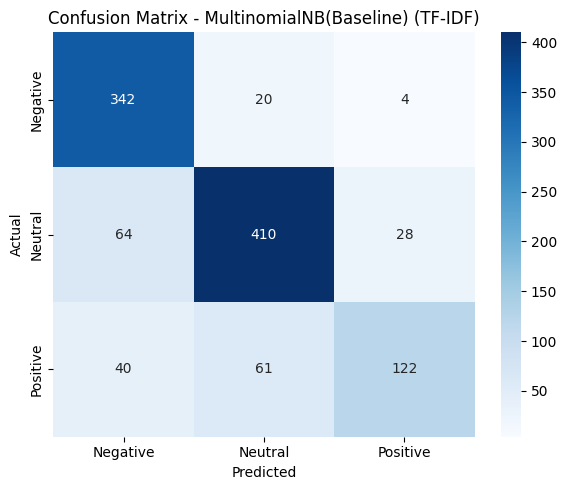


=== LinearSVC (Baseline) ===
Train time (s): 0.069
Infer  time (s): 0.003
Accuracy : 0.8121
Precision(macro) : 0.8076 | Recall(macro): 0.7843 | F1(macro): 0.7906

Classification report:
               precision    recall  f1-score   support

    Negative     0.7910    0.9098    0.8463       366
     Neutral     0.8353    0.8287    0.8320       502
    Positive     0.7965    0.6143    0.6937       223

    accuracy                         0.8121      1091
   macro avg     0.8076    0.7843    0.7906      1091
weighted avg     0.8125    0.8121    0.8085      1091

Confusion matrix (rows=true, cols=pred):
 [[333  29   4]
 [ 55 416  31]
 [ 33  53 137]]


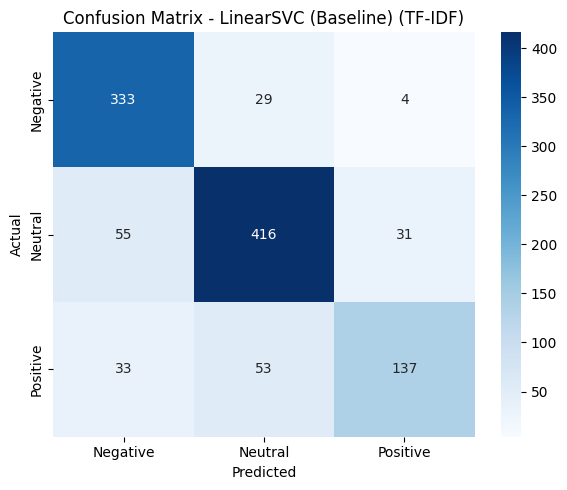


=== Random Forest (Baseline) ===
Train time (s): 12.149
Infer  time (s): 0.274
Accuracy : 0.8020
Precision(macro) : 0.8209 | Recall(macro): 0.7586 | F1(macro): 0.7709

Classification report:
               precision    recall  f1-score   support

    Negative     0.7724    0.9180    0.8390       366
     Neutral     0.8065    0.8466    0.8260       502
    Positive     0.8837    0.5112    0.6477       223

    accuracy                         0.8020      1091
   macro avg     0.8209    0.7586    0.7709      1091
weighted avg     0.8108    0.8020    0.7939      1091

Confusion matrix (rows=true, cols=pred):
 [[336  29   1]
 [ 63 425  14]
 [ 36  73 114]]


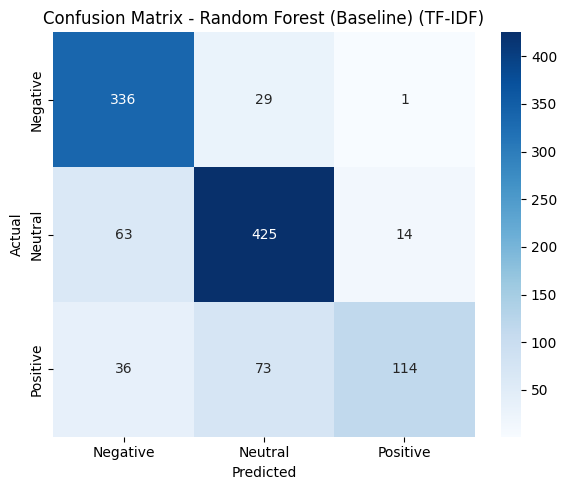

,Model,Params,Train_time_s,Infer_time_s,Accuracy,Precision_macro,Recall_macro,F1_macro
0,LinearSVC (Baseline),"{'C': 0.3, 'class_weight': 'balanced', 'max_it...",0.0686,0.0028,0.8121,0.8076,0.7843,0.7906
1,Random Forest (Baseline),"{'n_estimators': 300, 'max_features': 'sqrt', ...",12.1488,0.2737,0.8020,0.8209,0.7586,0.7709
2,MultinomialNB(Baseline),"{'alpha': 0.3, 'fit_prior': False}",0.0068,0.0010,0.8011,0.7980,0.7661,0.7718


In [ ]:
# Import library model Machine Learning dari Scikit-Learn
from sklearn.naive_bayes import MultinomialNB      # Naive Bayes
from sklearn.svm import LinearSVC                  # Linear SVM untuk teks
from sklearn.linear_model import LogisticRegression
import pandas as pd                                # Untuk DataFrame

# CATATAN:
# Kode ini mengasumsikan variabel/fungsi berikut SUDAH DIDEFINISIKAN
# di sel-sel sebelumnya di notebook Anda:
#
# - evaluate_model (fungsi kustom Anda untuk evaluasi)
# - X_train_tfidf, y_train (data latih)
# - X_test_tfidf, y_test (data uji)
# - RANDOM_STATE (variabel integer, misal: 42, untuk reproduktibilitas)


results = []                                     # Buat list kosong untuk menyimpan hasil evaluasi tiap model

# Multinomial Naive Bayes (Model Baseline)
nb_params = {
    # alpha (float, default=1.0)
    # Parameter smoothing (Laplace/Lidstone). Mencegah probabilitas nol.
    # 1.0 adalah nilai default yang standar untuk baseline.
    # Ini adalah parameter UTAMA yang akan di-tuning nanti (misal: 0.1, 0.5, 1.0).
    "alpha": 0.3,

    # fit_prior (bool, default=True)
    # Apakah model perlu mempelajari probabilitas prior kelas (P(y)).
    # True: Model akan memperhitungkan apakah satu kelas lebih dominan dari yg lain.
    "fit_prior": False

    # force_alpha (bool, default=True mulai v1.4)
    # Tidak perlu diset manual, default-nya sudah 'True'.
}

nb_clf = MultinomialNB(**nb_params)              # Inisialisasi model Naive Bayes

results.append(                                  # Tambahkan hasil evaluasi model Naive Bayes
    evaluate_model(
        "MultinomialNB(Baseline)",                         # Nama model
        nb_clf,                                  # Model yang digunakan
        X_train_tfidf, y_train,                  # Data training (fit)
        X_test_tfidf, y_test,                    # Data testing (predict)
        params_used=nb_params                    # Simpan parameter yang digunakan
    )
)

# Linear Support Vector Machine (SVC - Model Baseline)
# HANYA untuk kernel='linear'.

svm_params = {

    # C (float, default=1.0)
    # Parameter Regularisasi. Mengontrol 'hukuman' untuk misklasifikasi.
    # 1.0 adalah nilai default yang standar untuk baseline.
    # Ini adalah parameter UTAMA yang akan di-tuning nanti (misal: 0.1, 1, 10).
    "C": 0.3,

    # class_weight (dict atau 'balanced', default=None)
    # 'None' berarti semua kelas punya bobot '1'.
    # Jika data Anda tidak seimbang (imbalanced), ini bisa di-set 'balanced'.
    # Untuk baseline, 'None' adalah pilihan standar.
    "class_weight": 'balanced',
    "max_iter": 5000,
    # random_state (int, default=None)
    # Untuk memastikan hasil Anda bisa direproduksi (penting untuk skripsi).
    "random_state": RANDOM_STATE

    # Parameter yang TIDAK DIMASUKKAN (karena kernel='linear'):
    # - degree: Hanya untuk kernel='poly'
    # - gamma: Hanya untuk kernel='rbf', 'poly', 'sigmoid'
    # - coef0: Hanya untuk kernel='poly', 'sigmoid'
}

svm_clf = LinearSVC(**svm_params)               # Inisialisasi model linear SVC

results.append(                                  # Simpan hasil evaluasi model SVM
    evaluate_model(
        "LinearSVC (Baseline)",   # Nama model
        svm_clf,                                 # Model yang diuji
        X_train_tfidf, y_train,                  # Data train
        X_test_tfidf, y_test,                    # Data test
        params_used=svm_params                   # Simpan parameter SVM
    )
)

# Random Forest + GA (YANG DITAMBAHKAN)
# Parameter Random Forest untuk Teks:
rf_params = {
    # n_estimators: Jumlah pohon. 100-200 standar awal yang bagus.
    "n_estimators": 300,

    # Parameter Feature Selection Internal RF
    # max_features: Jumlah fitur yang dipertimbangkan saat mencari split terbaik.
    # 'sqrt' (akar kuadrat dari total fitur) adalah standar emas untuk klasifikasi.
    # Jika fitur sangat banyak (ribuan), 'sqrt' mempercepat proses & mencegah overfit.
    "max_features": "sqrt",

    # criterion: 'gini' atau 'entropy'. Gini biasanya lebih cepat.
    "criterion": "gini",

    # max_depth: Kedalaman pohon. None = sampai habis (bisa overfit).
    # Untuk teks, batasi sedikit (misal 50-100) atau biarkan None tapi atur min_samples.
    "max_depth": None,

    # min_samples_split: Minimal sampel untuk memecah node.
    # Angka lebih besar (misal 5-10) mencegah overfitting pada fitur jarang.
    "min_samples_split": 2,

    # min_samples_leaf: Minimal sampel di node daun (ujung).
    # 1 (default) bisa terlalu detail. 2 atau 3 membuat pohon lebih umum (general).
    "min_samples_leaf": 2,

    # class_weight: Penting untuk imbalanced data.
    "class_weight": "balanced_subsample",

    # n_jobs: -1 artinya pakai semua core CPU biar cepat trainingnya.
    "n_jobs": -1,

    "random_state": RANDOM_STATE
}

rf_clf = RandomForestClassifier(**rf_params)

results.append(
    evaluate_model(
        "Random Forest (Baseline)",
        rf_clf,
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        params_used=rf_params
    )
)

# Menyusun Ringkasan Hasil Semua Model
summary = (                                      # Ubah list results menjadi DataFrame
    pd.DataFrame(results)
      .sort_values("Accuracy", ascending=False)   # Urut dari yang tertinggi ke terendah
      .reset_index(drop=True)
)

summary                                      # Tampilkan hasil perbandingan model

# HYPERPARAMETER TUNING GRIDSEARCH

Menjalankan LANGKAH 10: Hyperparameter Tuning MultinomialNB (Baseline)
Memulai Hyperparameter Tuning untuk MultinomialNB (tanpa SMOTE)...

Parameter grid yang akan diuji (Baseline):
{'alpha': [0.1, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0, 10.0, 100.0], 'fit_prior': [True, False]} 

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Selesai GridSearchCV MultinomialNB (Baseline) dalam 3.58 detik

Hasil Tuning MultinomialNB (Baseline) [Ringkas]
Parameter terbaik (Baseline): {'alpha': 0.3, 'fit_prior': False}
Skor F1-macro CV terbaik (Baseline): 0.7876

Detail Hasil Iterasi Cross-Validation MultinomialNB (Baseline)


,param_alpha,param_fit_prior,mean_test_score,std_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
3,0.3,False,0.787615,0.002866,1,0.788289,0.788593,0.792038,0.785488,0.783670
1,0.1,False,0.787310,0.002514,2,0.788553,0.788978,0.785856,0.783111,0.790053
7,0.5,False,0.784705,0.004286,3,0.783909,0.787702,0.791303,0.780258,0.780353
0,0.1,True,0.784430,0.006390,4,0.779485,0.788443,0.795025,0.778077,0.781118
5,0.4,False,0.784112,0.006009,5,0.785193,0.786092,0.793805,0.777454,0.778015
2,0.3,True,0.777969,0.007886,6,0.764961,0.783912,0.784171,0.772588,0.784214
9,1.0,False,0.776111,0.009977,7,0.762520,0.784507,0.787793,0.766348,0.779388
4,0.4,True,0.773085,0.005502,8,0.764556,0.772630,0.779714,0.770280,0.778243
6,0.5,True,0.769855,0.004433,9,0.762890,0.770874,0.772631,0.767198,0.775682
11,2.0,False,0.768230,0.007694,10,0.756087,0.766876,0.779613,0.766562,0.772013



 Hasil Model FINAL MultinomialNB (Baseline + Tuning) di Data Uji

=== MultinomialNB (Baseline + GridSearch) ===
Train time (s): 0.007
Infer  time (s): 0.001
Accuracy : 0.8011
Precision(macro) : 0.7980 | Recall(macro): 0.7661 | F1(macro): 0.7718

Classification report:
               precision    recall  f1-score   support

    Negative     0.7668    0.9344    0.8424       366
     Neutral     0.8350    0.8167    0.8258       502
    Positive     0.7922    0.5471    0.6472       223

    accuracy                         0.8011      1091
   macro avg     0.7980    0.7661    0.7718      1091
weighted avg     0.8034    0.8011    0.7948      1091

Confusion matrix (rows=true, cols=pred):
 [[342  20   4]
 [ 64 410  28]
 [ 40  61 122]]


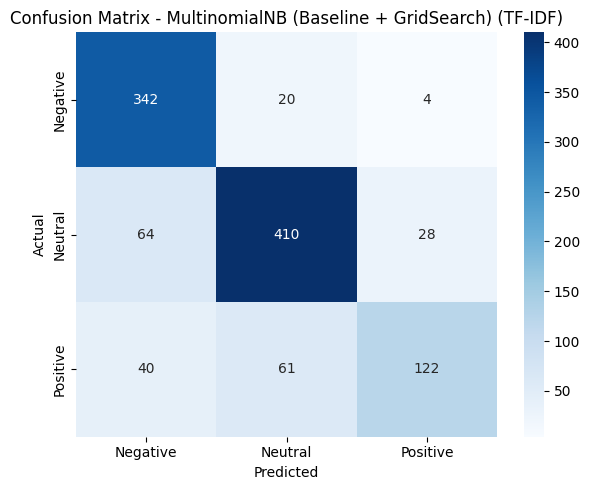

,Model,Params,Train_time_s,Infer_time_s,Accuracy,Precision_macro,Recall_macro,F1_macro
0,MultinomialNB (Baseline + GridSearch),"{'alpha': 0.3, 'fit_prior': False}",0.0067,0.0011,0.8011,0.798,0.7661,0.7718



 LANGKAH 10 SELESAI 



In [ ]:
# Hyperparameter Tuning MultinomialNB (Baseline, tanpa SMOTE)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
import pandas as pd
import time
from IPython.display import display

print("Menjalankan LANGKAH 10: Hyperparameter Tuning MultinomialNB (Baseline)")
print("Memulai Hyperparameter Tuning untuk MultinomialNB (tanpa SMOTE)...\n")

# Parameter grid untuk MultinomialNB (Baseline)
nb_param_grid_baseline = {
    "alpha": [0.1, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0, 10.0, 100.0],
    "fit_prior": [True, False]
}

print("Parameter grid yang akan diuji (Baseline):")
print(nb_param_grid_baseline, "\n")

# Estimator dasar untuk NB (Baseline)
nb_base_baseline = MultinomialNB()

# Inisialisasi GridSearchCV
nb_gs_baseline = GridSearchCV(
    estimator=nb_base_baseline,
    param_grid=nb_param_grid_baseline,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

# Latih GridSearchCV pada data TRAIN ASLI (tanpa SMOTE)
start_nb_base = time.time()
nb_gs_baseline.fit(X_train_tfidf, y_train)
dur_nb_base = time.time() - start_nb_base
print(f"\nSelesai GridSearchCV MultinomialNB (Baseline) dalam {dur_nb_base:.2f} detik\n")

# Hasil Ringkas
print("Hasil Tuning MultinomialNB (Baseline) [Ringkas]")
print("Parameter terbaik (Baseline):", nb_gs_baseline.best_params_)
print(f"Skor F1-macro CV terbaik (Baseline): {nb_gs_baseline.best_score_:.4f}\n")

# Detail cv_results_
print("Detail Hasil Iterasi Cross-Validation MultinomialNB (Baseline)")

cv_nb_base = pd.DataFrame(nb_gs_baseline.cv_results_)
cols_nb_base = [
    "param_alpha", "param_fit_prior",
    "mean_test_score", "std_test_score", "rank_test_score",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score"
]
cols_nb_base = [c for c in cols_nb_base if c in cv_nb_base.columns]

display(cv_nb_base.sort_values("rank_test_score")[cols_nb_base])

# Ambil model NB terbaik (Baseline)
best_nb_baseline = nb_gs_baseline.best_estimator_

# Evaluasi model FINAL NB Baseline di data uji
print("\n Hasil Model FINAL MultinomialNB (Baseline + Tuning) di Data Uji")

results_nb_baseline_tuned = []
results_nb_baseline_tuned.append(
    evaluate_model(
        "MultinomialNB (Baseline + GridSearch)",
        best_nb_baseline,
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        params_used=nb_gs_baseline.best_params_
    )
)

summary_nb_baseline_tuned = pd.DataFrame(results_nb_baseline_tuned)
display(summary_nb_baseline_tuned)

print("\n LANGKAH 10 SELESAI \n")

 Menjalankan LANGKAH 8: Hyperparameter Tuning (GridSearchCV - BASELINE)
Memulai Hyperparameter Tuning untuk LinearSVC (Baseline, class_weight='balanced')...
Ini mungkin akan memakan waktu BEBERAPA MENIT...

Parameter grid yang akan diuji: {'C': [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 5, 10, 100], 'class_weight': [None, 'balanced']}
Fitting 5 folds for each of 26 candidates, totalling 130 fits

Selesai GridSearchCV (Baseline) dalam 20.40 detik

--- Hasil Tuning (Ringkas - BASELINE) ---
Parameter terbaik: {'C': 0.3, 'class_weight': 'balanced'}
Skor F1-macro CV terbaik: 0.8145

--- Detail Hasil Iterasi Cross-Validation (Baseline) ---


,param_C,mean_test_score,std_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
9,0.30,0.814471,0.007283,1,0.808196,0.808025,0.811118,0.817827,0.827189
11,0.40,0.813377,0.008890,2,0.802191,0.808769,0.814466,0.812381,0.829080
13,0.50,0.813265,0.006408,3,0.804894,0.809438,0.817613,0.811237,0.823143
15,1.00,0.812967,0.004322,4,0.807422,0.815115,0.813942,0.808973,0.819380
16,2.00,0.810449,0.001695,5,0.809232,0.813398,0.811293,0.808881,0.809439
7,0.20,0.808573,0.006416,6,0.802266,0.801037,0.807980,0.817322,0.814260
14,1.00,0.808442,0.004769,7,0.808095,0.809075,0.805649,0.802545,0.816845
17,2.00,0.808038,0.003830,8,0.806982,0.807760,0.806430,0.803798,0.815220
19,3.00,0.808005,0.001911,9,0.807411,0.807147,0.807369,0.806350,0.811749
18,3.00,0.806599,0.003304,10,0.804802,0.807223,0.807746,0.801630,0.811596



 Hasil Model FINAL (Setelah Tuning - Baseline)

=== LinearSVC (Baseline Tuned) ===
Train time (s): 0.037
Infer  time (s): 0.001
Accuracy : 0.8121
Precision(macro) : 0.8076 | Recall(macro): 0.7843 | F1(macro): 0.7906

Classification report:
               precision    recall  f1-score   support

    Negative     0.7910    0.9098    0.8463       366
     Neutral     0.8353    0.8287    0.8320       502
    Positive     0.7965    0.6143    0.6937       223

    accuracy                         0.8121      1091
   macro avg     0.8076    0.7843    0.7906      1091
weighted avg     0.8125    0.8121    0.8085      1091

Confusion matrix (rows=true, cols=pred):
 [[333  29   4]
 [ 55 416  31]
 [ 33  53 137]]


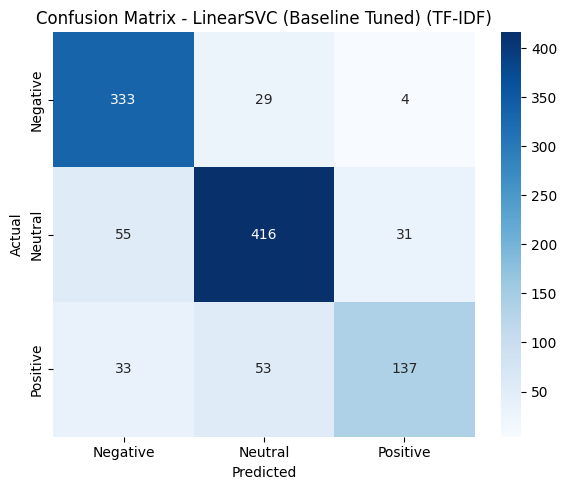

,Model,Params,Train_time_s,Infer_time_s,Accuracy,Precision_macro,Recall_macro,F1_macro
0,LinearSVC (Baseline Tuned),"{'C': 0.3, 'class_weight': 'balanced'}",0.037,0.0006,0.8121,0.8076,0.7843,0.7906



 LANGKAH 8 SELESAI 



In [ ]:
# HYPERPARAMETER TUNING UNTUK MODEL BASELINE (TANPA SMOTE)

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
import pandas as pd
import time
from IPython.display import display

print(" Menjalankan LANGKAH 8: Hyperparameter Tuning (GridSearchCV - BASELINE)")
print("Memulai Hyperparameter Tuning untuk LinearSVC (Baseline, class_weight='balanced')...")
print("Ini mungkin akan memakan waktu BEBERAPA MENIT...\n")

# 1. Parameter Grid (tanpa kernel/gamma, khusus LinearSVC)
param_grid_baseline = {
    "C": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 5, 10, 100],
    "class_weight": [None, "balanced"], # <--- PERUBAHAN DI SINI


    # kalau mau: "loss": ["hinge", "squared_hinge"]
}

print("Parameter grid yang akan diuji:", param_grid_baseline)

# 2. Buat estimator baseline
svc_base = LinearSVC(
    max_iter=5000,
    random_state=RANDOM_STATE
)

# 3. Inisialisasi GridSearchCV
gs_baseline = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid_baseline,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

# 4. Fit GridSearch
start = time.time()
gs_baseline.fit(X_train_tfidf, y_train)
print(f"\nSelesai GridSearchCV (Baseline) dalam {time.time() - start:.2f} detik\n")

# 5A. Hasil Ringkas
print("--- Hasil Tuning (Ringkas - BASELINE) ---")
print("Parameter terbaik:", gs_baseline.best_params_)
print(f"Skor F1-macro CV terbaik: {gs_baseline.best_score_:.4f}\n")

# 5B. Detail cv_results_
print("--- Detail Hasil Iterasi Cross-Validation (Baseline) ---")

cv_df = pd.DataFrame(gs_baseline.cv_results_)
cols = [
    "param_C",
    "mean_test_score", "std_test_score", "rank_test_score",
    "split0_test_score", "split1_test_score", "split2_test_score",
    "split3_test_score", "split4_test_score"
]
cols = [c for c in cols if c in cv_df.columns]
display(cv_df.sort_values("rank_test_score")[cols])

# 6. Model terbaik (baseline)
best_svc_baseline = gs_baseline.best_estimator_

# 7. Evaluasi model FINAL baseline
print("\n Hasil Model FINAL (Setelah Tuning - Baseline)")

results_tuned_baseline = []
results_tuned_baseline.append(
    evaluate_model(
        "LinearSVC (Baseline Tuned)",
        best_svc_baseline,
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        params_used=gs_baseline.best_params_
    )
)

summary_svc_tuned_baseline = pd.DataFrame(results_tuned_baseline)
display(summary_svc_tuned_baseline)

print("\n LANGKAH 8 SELESAI \n")

In [ ]:
# Hyperparameter Tuning Random Forest (Baseline - CPU Optimized)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import time
from IPython.display import display

print("Hyperparameter Tuning Random Forest (CPU Optimized)")

# Parameter Grid (disederhanakan agar cepat & akurat)
rf_param_grid = {
    "n_estimators": [200, 500, 1000],           # jumlah pohon optimal untuk teks
    "max_features": ["sqrt", "log2"],             # sqrt paling stabil di teks
    "min_samples_split": [5, 10, 50],     # mengendalikan overfitting
    "min_samples_leaf": [1, 2, 5],           # leaf kecil untuk TF-IDF
    "max_depth": [None, 30],              # None = full depth
    "criterion": ["gini", "entropy"],     # gini dominan, entropy dicoba
    "class_weight": ["balanced", None]    # imbalanced dataset support
}

print("Parameter grid yang diuji:")
print(rf_param_grid)

# Estimator RF dasar
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1   # pakai semua core CPU Colab
)

# GridSearchCV
rf_gs = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=3,                    # CV=3 sudah cukup dan lebih cepat
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

# Fit GridSearch
start = time.time()
rf_gs.fit(X_train_tfidf, y_train)
dur = time.time() - start

print(f"\nSelesai GridSearch Random Forest dalam {dur:.2f} detik")
print("Best Params:", rf_gs.best_params_)
print("Best F1-macro CV:", rf_gs.best_score_)

# Detail hasil CV
cv_rf_df = pd.DataFrame(rf_gs.cv_results_)
cols = [
    "param_n_estimators", "param_max_features", "param_min_samples_split",
    "param_min_samples_leaf", "param_max_depth", "param_criterion",
    "param_class_weight",
    "mean_test_score", "std_test_score", "rank_test_score"
]

cols = [c for c in cols if c in cv_rf_df.columns]
display(cv_rf_df.sort_values("rank_test_score")[cols])

# Evaluasi model terbaik di test-set
best_rf = rf_gs.best_estimator_

print("\n Evaluasi Model FINAL Random Forest (Tuned)")
results_rf_final = []

results_rf_final.append(
    evaluate_model(
        "Random Forest (Tuned)",
        best_rf,
        X_train_tfidf, y_train,
        X_test_tfidf, y_test,
        params_used=rf_gs.best_params_
    )
)

summary_rf_final = pd.DataFrame(results_rf_final)
display(summary_rf_final)

print("\n RF Tuning Selesai \n")

Hyperparameter Tuning Random Forest (CPU Optimized)
Parameter grid yang diuji:
{'n_estimators': [200, 500, 1000], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [5, 10, 50], 'min_samples_leaf': [1, 2, 5], 'max_depth': [None, 30], 'criterion': ['gini', 'entropy'], 'class_weight': ['balanced', None]}
Fitting 3 folds for each of 432 candidates, totalling 1296 fits


KeyboardInterrupt: 

Random Forest tidak dilakukan tuning mendalam karena durasi training yang sangat lama pada data TF-IDF berdimensi besar